###  Setup and Import

In [1]:
import sys
sys.path.append('D:/Neural-Pipeline/source')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis_pseudopopulation.AccumulatedEvidenceAnalyzer import AccumulatedEvidenceAnalyzer
from pathlib import Path

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Functions

In [2]:
def define_rt_adaptive_windows(matched_early, matched_late, rt_buffer_early=0.1, rt_buffer_late=0.1):
    """
    Define time windows based on RT distribution.
    
    Parameters:
    -----------
    matched_early : dict
        Early (stimulus-aligned) data
    matched_late : dict
        Late (saccade-aligned) data
    rt_buffer_early : float
        How much to subtract from median RT for early window end (seconds)
    rt_buffer_late : float
        How much before saccade to end late window (seconds)
    
    Returns:
    --------
    early_window : tuple (start, end)
    late_window : tuple (start, end)
    rt_info : dict with RT statistics
    """
    rt = matched_early['RT']
    
    # RT statistics
    min_rt = np.min(rt)
    max_rt = np.max(rt)
    median_rt = np.median(rt)
    mean_rt = np.mean(rt)
    
    print(f"\n  RT Statistics:")
    print(f"    Min RT:    {min_rt:.3f}s")
    print(f"    Max RT:    {max_rt:.3f}s")
    print(f"    Median RT: {median_rt:.3f}s")
    print(f"    Mean RT:   {mean_rt:.3f}s")
    
    # Early window: 0 to (median_RT - buffer)
    early_window = (0.0, median_rt - rt_buffer_early)
    
    # Late window: -(median_RT - buffer) to -buffer (saccade-aligned)
    late_window_start = -(median_rt - rt_buffer_late)
    late_window_end = -rt_buffer_late
    late_window = (late_window_start, late_window_end)
    
    print(f"\n  Adaptive Windows:")
    print(f"    Early: {early_window[0]:.3f} to {early_window[1]:.3f}s (stimulus-aligned)")
    print(f"    Late:  {late_window[0]:.3f} to {late_window[1]:.3f}s (saccade-aligned)")
    
    # Validate windows
    if early_window[1] <= early_window[0]:
        print(f"  ⚠ WARNING: Early window invalid! Setting to (0.0, 0.3)s")
        early_window = (0.0, 0.3)
    
    if late_window[0] >= late_window[1]:
        print(f"  ⚠ WARNING: Late window invalid! Setting to (-0.3, -0.1)s")
        late_window = (-0.3, -0.1)
    
    rt_info = {
        'min': min_rt,
        'max': max_rt,
        'median': median_rt,
        'mean': mean_rt,
        'n_trials': len(rt),
        'early_buffer': rt_buffer_early,
        'late_buffer': rt_buffer_late
    }
    
    return early_window, late_window, rt_info


### Core Analysis Functions

def initialize_analyzer(subject, dates, regress_type):
    """Initialize the AccumulatedEvidenceAnalyzer"""
    analyzer = AccumulatedEvidenceAnalyzer(
        subject=subject,
        dates=dates,
        regress_type=regress_type
    )
    print(f"Initialized analyzer for {subject}")
    print(f"Sessions: {len(dates)}")
    print(f"Results dir: {analyzer.results_dir}")
    print(f"Save dir: {analyzer.save_dir}")
    return analyzer


def load_data_for_condition(analyzer, areas, target, early_alignment, late_alignment, condition):
    """Load data for specified areas and condition."""
    print("="*60)
    print(f"LOADING DATA FOR {target.upper()} DECODER")
    print(f"Condition: {condition}")
    print("="*60)
    
    data_by_area = {}
    
    for area in areas:
        print(f"\nLoading {area}...")
        
        # Ensure condition is a list
        cond_list = [condition] if isinstance(condition, tuple) else condition
        
        # Early window data (stimulus-aligned)
        data_early = analyzer.load_all_sessions(area, target, early_alignment, conditions=cond_list)
        
        # Late window data (saccade-aligned)
        data_late = analyzer.load_all_sessions(area, target, late_alignment, conditions=cond_list)
        
        if data_early is None or data_late is None:
            print(f"  Warning: No data for {area}")
            continue
        
        data_by_area[area] = {
            'early': data_early,
            'late': data_late
        }
        
        print(f"  Early ({early_alignment}): {data_early['n_trials']} trials, "
              f"{data_early['dv_matrix'].shape[1]} timepoints")
        print(f"  Late ({late_alignment}): {data_late['n_trials']} trials, "
              f"{data_late['dv_matrix'].shape[1]} timepoints")
    
    print("\nData loading complete!")
    return data_by_area


def match_and_define_windows(analyzer, data_by_area, early_window, late_window, 
                             early_alignment, late_alignment, use_rt_adaptive=False,
                             rt_buffer_early=0.1, rt_buffer_late=0.1):
    """Match trials across areas and define time windows."""
    print("\n" + "="*60)
    print("MATCHING TRIALS ACROSS AREAS")
    print("="*60)
    
    matched_early = analyzer.match_trials_across_areas(
        data_by_area['MST']['early'],
        data_by_area['VPS']['early']
    )
    
    matched_late = analyzer.match_trials_across_areas(
        data_by_area['MST']['late'],
        data_by_area['VPS']['late']
    )
    
    print(f"Matched early trials: {matched_early['n_trials']}")
    print(f"Matched late trials: {matched_late['n_trials']}")
    
    # Get RT-adaptive windows if requested
    rt_info = None
    if use_rt_adaptive:
        print("\n" + "="*60)
        print("COMPUTING RT-ADAPTIVE TIME WINDOWS")
        print("="*60)
        early_window, late_window, rt_info = define_rt_adaptive_windows(
            matched_early, matched_late, rt_buffer_early, rt_buffer_late
        )
    
    # Define time windows
    print(f"\nTime windows:")
    print(f"  Early: {early_window[0]:.3f} to {early_window[1]:.3f}s ({early_alignment})")
    print(f"  Late: {late_window[0]:.3f} to {late_window[1]:.3f}s ({late_alignment})")
    
    # Get time indices
    early_time_axis = matched_early['time_axis']
    late_time_axis = matched_late['time_axis']
    
    early_indices = analyzer.define_time_window(early_time_axis, early_window[0], early_window[1])
    late_indices = analyzer.define_time_window(late_time_axis, late_window[0], late_window[1])
    
    print(f"\nTime points in windows:")
    print(f"  Early: {np.sum(early_indices)} points")
    print(f"  Late: {np.sum(late_indices)} points")
    
    return matched_early, matched_late, early_time_axis, late_time_axis, early_indices, late_indices, rt_info


### NEW: Sigma Selection and Temporal Scanning Functions

def select_optimal_sigmas(analyzer, matched_early, matched_late, early_time_axis, late_time_axis,
                         early_indices, late_indices, sigma_values=None, n_centers=4,
                         target='choice', condition_label=''):
    """
    Select optimal sigma for each area and time window.
    
    Returns:
    --------
    dict with optimal sigmas and detailed results for each area/window
    """
    if sigma_values is None:
        sigma_values = np.linspace(0.01, 0.3, 20)  # Changed default range
    
    print("\n" + "="*60)
    print("SELECTING OPTIMAL SIGMA VALUES")
    print("="*60)
    print(f"Testing sigma range: [{sigma_values[0]:.3f}, {sigma_values[-1]:.3f}] with {len(sigma_values)} values")
    print(f"Testing at {n_centers} center positions per window")
    print(f"Selection criterion: MAXIMUM AUC across centers")
    
    results = {}
    
    # Early window - MST
    print("\n--- MST Early (stimulus-aligned) ---")
    results['mst_early'] = analyzer.select_optimal_sigma_for_area(
        matched_early['dv_mst'], early_time_axis, early_indices,
        matched_early['choice'], sigma_values, n_centers
    )
    print(f"Optimal sigma: {results['mst_early']['optimal_sigma']:.3f}")
    print(f"Max AUC by sigma: min={np.min(results['mst_early']['max_auc_by_sigma']):.3f}, "
          f"max={np.max(results['mst_early']['max_auc_by_sigma']):.3f}")
    
    # Early window - VPS
    print("\n--- VPS Early (stimulus-aligned) ---")
    results['vps_early'] = analyzer.select_optimal_sigma_for_area(
        matched_early['dv_vps'], early_time_axis, early_indices,
        matched_early['choice'], sigma_values, n_centers
    )
    print(f"Optimal sigma: {results['vps_early']['optimal_sigma']:.3f}")
    print(f"Max AUC by sigma: min={np.min(results['vps_early']['max_auc_by_sigma']):.3f}, "
          f"max={np.max(results['vps_early']['max_auc_by_sigma']):.3f}")
    
    # Late window - MST
    print("\n--- MST Late (saccade-aligned) ---")
    results['mst_late'] = analyzer.select_optimal_sigma_for_area(
        matched_late['dv_mst'], late_time_axis, late_indices,
        matched_late['choice'], sigma_values, n_centers
    )
    print(f"Optimal sigma: {results['mst_late']['optimal_sigma']:.3f}")
    print(f"Max AUC by sigma: min={np.min(results['mst_late']['max_auc_by_sigma']):.3f}, "
          f"max={np.max(results['mst_late']['max_auc_by_sigma']):.3f}")
    
    # Late window - VPS
    print("\n--- VPS Late (saccade-aligned) ---")
    results['vps_late'] = analyzer.select_optimal_sigma_for_area(
        matched_late['dv_vps'], late_time_axis, late_indices,
        matched_late['choice'], sigma_values, n_centers
    )
    print(f"Optimal sigma: {results['vps_late']['optimal_sigma']:.3f}")
    print(f"Max AUC by sigma: min={np.min(results['vps_late']['max_auc_by_sigma']):.3f}, "
          f"max={np.max(results['vps_late']['max_auc_by_sigma']):.3f}")
    
    # Visualize sigma selection
    plot_sigma_selection(analyzer, results, target, condition_label)
    
    return results


def plot_sigma_selection(analyzer, sigma_results, target, condition_label):
    """Visualize the sigma selection process."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    conditions = [
        ('mst_early', 'MST Early', 'purple', 0, 0),
        ('vps_early', 'VPS Early', 'orange', 0, 1),
        ('mst_late', 'MST Late', 'purple', 1, 0),
        ('vps_late', 'VPS Late', 'orange', 1, 1)
    ]
    
    # Left and middle columns: AUC curves for each sigma at different centers
    for key, title, color, row, col in conditions:
        ax = axes[row, col]
        
        res = sigma_results[key]
        sigma_values = res['sigma_values']
        auc_grid = res['auc_grid']
        center_positions = res['center_positions']
        optimal_sigma = res['optimal_sigma']
        
        # Plot AUC for each sigma at each center (faint lines)
        for j, sigma in enumerate(sigma_values):
            alpha = 0.2
            linewidth = 1
            ax.plot(center_positions, auc_grid[:, j], '-', 
                   alpha=alpha, linewidth=linewidth, color='gray')
        
        # Highlight optimal sigma (bold red line)
        opt_idx = np.where(sigma_values == optimal_sigma)[0][0]
        ax.plot(center_positions, auc_grid[:, opt_idx], 'o-', 
               linewidth=3, markersize=8, color='red', 
               label=f'Optimal: σ={optimal_sigma:.3f}')
        
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Center Position (s)', fontsize=11)
        ax.set_ylabel('AUC', fontsize=11)
        ax.set_title(f'{title}\nOptimal σ={optimal_sigma:.3f}', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.45, 1.0])
    
    # Right column: Max AUC vs Sigma
    # Top right: Early window
    ax = axes[0, 2]
    for key, title, color in [('mst_early', 'MST Early', 'purple'), 
                               ('vps_early', 'VPS Early', 'orange')]:
        res = sigma_results[key]
        ax.plot(res['sigma_values'], res['max_auc_by_sigma'], 'o-', 
               color=color, linewidth=2.5, markersize=6, label=title)
        opt_sigma = res['optimal_sigma']
        opt_idx = np.where(res['sigma_values'] == opt_sigma)[0][0]
        ax.plot(opt_sigma, res['max_auc_by_sigma'][opt_idx], '*', 
               color=color, markersize=20, markeredgecolor='black', markeredgewidth=2)
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Sigma (s)', fontsize=11)
    ax.set_ylabel('Max AUC', fontsize=11)
    ax.set_title('Early Window: Max AUC vs Sigma', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.45, 1.0])
    
    # Bottom right: Late window
    ax = axes[1, 2]
    for key, title, color in [('mst_late', 'MST Late', 'purple'), 
                               ('vps_late', 'VPS Late', 'orange')]:
        res = sigma_results[key]
        ax.plot(res['sigma_values'], res['max_auc_by_sigma'], 'o-', 
               color=color, linewidth=2.5, markersize=6, label=title)
        opt_sigma = res['optimal_sigma']
        opt_idx = np.where(res['sigma_values'] == opt_sigma)[0][0]
        ax.plot(opt_sigma, res['max_auc_by_sigma'][opt_idx], '*', 
               color=color, markersize=20, markeredgecolor='black', markeredgewidth=2)
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Sigma (s)', fontsize=11)
    ax.set_ylabel('Max AUC', fontsize=11)
    ax.set_title('Late Window: Max AUC vs Sigma', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.45, 1.0])
    
    plt.tight_layout()
    plt.savefig(analyzer.save_dir / 'figures' / f'sigma_selection_{target}_{condition_label}.png',
               dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def scan_temporal_profiles(analyzer, matched_early, matched_late, early_time_axis, late_time_axis,
                           early_indices, late_indices, sigma_results, n_scan_centers=20,
                           target='choice', condition_label=''):
    """
    Scan temporal profiles using optimal sigmas.
    
    Returns:
    --------
    dict with temporal scan results for early and late windows
    """
    print("\n" + "="*60)
    print("SCANNING TEMPORAL PROFILES WITH OPTIMAL SIGMAS")
    print("="*60)
    
    # Extract optimal sigmas
    sigma_mst_early = sigma_results['mst_early']['optimal_sigma']
    sigma_vps_early = sigma_results['vps_early']['optimal_sigma']
    sigma_mst_late = sigma_results['mst_late']['optimal_sigma']
    sigma_vps_late = sigma_results['vps_late']['optimal_sigma']
    
    print(f"\nOptimal sigmas:")
    print(f"  MST Early: {sigma_mst_early:.3f}s")
    print(f"  VPS Early: {sigma_vps_early:.3f}s")
    print(f"  MST Late:  {sigma_mst_late:.3f}s")
    print(f"  VPS Late:  {sigma_vps_late:.3f}s")
    
    # Scan early window
    print(f"\nScanning early window with {n_scan_centers} centers...")
    scan_early = analyzer.scan_temporal_profile_with_optimal_sigma(
        matched_early['dv_mst'], matched_early['dv_vps'],
        early_time_axis, early_indices, matched_early['choice'],
        sigma_mst_early, sigma_vps_early, n_scan_centers
    )
    
    # Scan late window
    print(f"Scanning late window with {n_scan_centers} centers...")
    scan_late = analyzer.scan_temporal_profile_with_optimal_sigma(
        matched_late['dv_mst'], matched_late['dv_vps'],
        late_time_axis, late_indices, matched_late['choice'],
        sigma_mst_late, sigma_vps_late, n_scan_centers
    )
    
    # Visualize temporal profiles
    plot_temporal_profiles(analyzer, scan_early, scan_late, target, condition_label)
    
    return {
        'early': scan_early,
        'late': scan_late
    }


def plot_temporal_profiles(analyzer, scan_early, scan_late, target, condition_label):
    """Visualize how information content changes across time - 2x2 layout."""
    
    # DEBUG: Print what we're trying to plot
    print("\n" + "="*60)
    print("DEBUG: Plotting temporal profiles")
    print("="*60)
    print(f"Early centers: {scan_early['center_positions'][:3]}...{scan_early['center_positions'][-3:]}")
    print(f"Early AUC MST: {scan_early['auc_mst'][:3]}...{scan_early['auc_mst'][-3:]}")
    print(f"Early AUC VPS: {scan_early['auc_vps'][:3]}...{scan_early['auc_vps'][-3:]}")
    print(f"Early coef MST: {scan_early['coef_mst'][:3]}...{scan_early['coef_mst'][-3:]}")
    print(f"Early coef VPS: {scan_early['coef_vps'][:3]}...{scan_early['coef_vps'][-3:]}")
    print(f"\nLate centers: {scan_late['center_positions'][:3]}...{scan_late['center_positions'][-3:]}")
    print(f"Late AUC MST: {scan_late['auc_mst'][:3]}...{scan_late['auc_mst'][-3:]}")
    print(f"Late coef MST: {scan_late['coef_mst'][:3]}...{scan_late['coef_mst'][-3:]}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Early window plots
    centers_early = scan_early['center_positions']
    
    # Top-left: Early Window AUCs and Accuracy
    ax = axes[0, 0]
    
    # Plot each line separately with explicit data
    line1 = ax.plot(centers_early, scan_early['auc_mst'], 'o-', color='purple', 
                    linewidth=2.5, markersize=6, label=f"MST AUC (σ={scan_early['sigma_mst']:.3f})")
    line2 = ax.plot(centers_early, scan_early['auc_vps'], 'o-', color='orange', 
                    linewidth=2.5, markersize=6, label=f"VPS AUC (σ={scan_early['sigma_vps']:.3f})")
    line3 = ax.plot(centers_early, scan_early['auc_combined'], 'o-', color='green', 
                    linewidth=2.5, markersize=6, label='Combined AUC')
    line4 = ax.plot(centers_early, scan_early['accuracy_combined'], 's--', color='red', 
                    linewidth=2, markersize=5, label='Combined Accuracy', alpha=0.7)
    
    print(f"\nPlotted lines in top-left: {len(line1)}, {len(line2)}, {len(line3)}, {len(line4)}")
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Gaussian Center (s)', fontsize=12)
    ax.set_ylabel('AUC / Accuracy', fontsize=12)
    ax.set_title('Early Window: Performance Metrics', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.45, 1.0])
    
    # Explicitly set x-axis limits based on data
    ax.set_xlim([centers_early.min() - 0.05, centers_early.max() + 0.05])
    
    # Bottom-left: Early Window Coefficients
    ax = axes[1, 0]
    ax.plot(centers_early, scan_early['coef_mst'], 'o-', color='purple', 
           linewidth=2.5, markersize=6, label='β_MST')
    ax.plot(centers_early, scan_early['coef_vps'], 'o-', color='orange', 
           linewidth=2.5, markersize=6, label='β_VPS')
    ax.plot(centers_early, scan_early['intercept'], 'd-', color='gray', 
           linewidth=2, markersize=5, label='Intercept', alpha=0.6)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Gaussian Center (s)', fontsize=12)
    ax.set_ylabel('Coefficient', fontsize=12)
    ax.set_title('Early Window: Logistic Regression Coefficients', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([centers_early.min() - 0.05, centers_early.max() + 0.05])
    
    # Late window plots
    centers_late = scan_late['center_positions']
    
    # Top-right: Late Window AUCs and Accuracy
    ax = axes[0, 1]
    ax.plot(centers_late, scan_late['auc_mst'], 'o-', color='purple', 
           linewidth=2.5, markersize=6, label=f"MST AUC (σ={scan_late['sigma_mst']:.3f})")
    ax.plot(centers_late, scan_late['auc_vps'], 'o-', color='orange', 
           linewidth=2.5, markersize=6, label=f"VPS AUC (σ={scan_late['sigma_vps']:.3f})")
    ax.plot(centers_late, scan_late['auc_combined'], 'o-', color='green', 
           linewidth=2.5, markersize=6, label='Combined AUC')
    ax.plot(centers_late, scan_late['accuracy_combined'], 's--', color='red', 
           linewidth=2, markersize=5, label='Combined Accuracy', alpha=0.7)
    
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Gaussian Center (s)', fontsize=12)
    ax.set_ylabel('AUC / Accuracy', fontsize=12)
    ax.set_title('Late Window: Performance Metrics', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.45, 1.0])
    ax.set_xlim([centers_late.min() - 0.05, centers_late.max() + 0.05])
    
    # Bottom-right: Late Window Coefficients
    ax = axes[1, 1]
    ax.plot(centers_late, scan_late['coef_mst'], 'o-', color='purple', 
           linewidth=2.5, markersize=6, label='β_MST')
    ax.plot(centers_late, scan_late['coef_vps'], 'o-', color='orange', 
           linewidth=2.5, markersize=6, label='β_VPS')
    ax.plot(centers_late, scan_late['intercept'], 'd-', color='gray', 
           linewidth=2, markersize=5, label='Intercept', alpha=0.6)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.set_xlabel('Gaussian Center (s)', fontsize=12)
    ax.set_ylabel('Coefficient', fontsize=12)
    ax.set_title('Late Window: Logistic Regression Coefficients', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([centers_late.min() - 0.05, centers_late.max() + 0.05])
    
    plt.tight_layout()
    plt.savefig(analyzer.save_dir / 'figures' / f'temporal_profiles_{target}_{condition_label}.png',
               dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def fit_final_model_at_best_centers(analyzer, matched_early, matched_late, early_time_axis, late_time_axis,
                                    early_indices, late_indices, scan_results, sigma_results,
                                    bootstrap_iterations=1000, target='choice', condition_label=''):
    """
    Fit final logistic model using the most informative time points (highest combined AUC).
    
    Returns:
    --------
    dict with final model results and bootstrap CIs
    """
    print("\n" + "="*60)
    print("FITTING FINAL MODEL AT OPTIMAL CENTERS")
    print("="*60)
    
    # Find best centers (highest combined AUC)
    scan_early = scan_results['early']
    scan_late = scan_results['late']
    
    best_idx_early = np.argmax(scan_early['auc_combined'])
    best_idx_late = np.argmax(scan_late['auc_combined'])
    
    best_center_early = scan_early['center_positions'][best_idx_early]
    best_center_late = scan_late['center_positions'][best_idx_late]
    
    print(f"\nOptimal centers (highest combined AUC):")
    print(f"  Early: {best_center_early:.3f}s (AUC={scan_early['auc_combined'][best_idx_early]:.3f})")
    print(f"  Late:  {best_center_late:.3f}s (AUC={scan_late['auc_combined'][best_idx_late]:.3f})")
    
    # Get optimal sigmas
    sigma_mst_early = sigma_results['mst_early']['optimal_sigma']
    sigma_vps_early = sigma_results['vps_early']['optimal_sigma']
    sigma_mst_late = sigma_results['mst_late']['optimal_sigma']
    sigma_vps_late = sigma_results['vps_late']['optimal_sigma']
    
    print(f"\nIntegrating DVs with optimal parameters...")
    
    # Integrate DVs at optimal centers
    cum_mst_early = analyzer.integrate_dv_gaussian(
        matched_early['dv_mst'], early_time_axis, early_indices,
        best_center_early, sigma_mst_early
    )
    cum_vps_early = analyzer.integrate_dv_gaussian(
        matched_early['dv_vps'], early_time_axis, early_indices,
        best_center_early, sigma_vps_early
    )
    cum_mst_late = analyzer.integrate_dv_gaussian(
        matched_late['dv_mst'], late_time_axis, late_indices,
        best_center_late, sigma_mst_late
    )
    cum_vps_late = analyzer.integrate_dv_gaussian(
        matched_late['dv_vps'], late_time_axis, late_indices,
        best_center_late, sigma_vps_late
    )
    
    # Prepare regression data
    X = np.column_stack([cum_mst_early, cum_vps_early, cum_mst_late, cum_vps_late])
    y = matched_early['choice']
    feature_names = ['MST_early', 'VPS_early', 'MST_late', 'VPS_late']
    
    print(f"\nFitting logistic regression...")
    print(f"  Features: {', '.join(feature_names)}")
    print(f"  Samples: {len(y)}")
    
    # Fit model
    model_results = analyzer.fit_logistic_model(X, y)
    
    print(f"\nModel performance:")
    print(f"  AUC: {model_results['auc']:.3f}")
    print(f"  Accuracy: {model_results['accuracy']:.3f}")
    
    print(f"\nCoefficients:")
    for name, coef in zip(feature_names, model_results['coefficients']):
        print(f"  {name:12s}: {coef:+.4f}")
    
    # Bootstrap if requested
    bootstrap_results = None
    if bootstrap_iterations > 0:
        print(f"\nBootstrapping ({bootstrap_iterations} iterations)...")
        bootstrap_results = analyzer.bootstrap_coefficients(X, y, n_iterations=bootstrap_iterations)
        
        print(f"\nBootstrap results (95% CI):")
        for i, name in enumerate(feature_names):
            mean = bootstrap_results['coefficients_mean'][i]
            ci_low = bootstrap_results['ci_lower'][i]
            ci_high = bootstrap_results['ci_upper'][i]
            print(f"  {name:12s}: {mean:+.4f} [{ci_low:+.4f}, {ci_high:+.4f}]")
    
    # Visualize
    plot_final_model_results(analyzer, model_results, bootstrap_results, feature_names, 
                            target, condition_label)
    
    return {
        'model_results': model_results,
        'bootstrap_results': bootstrap_results,
        'feature_names': feature_names,
        'best_center_early': best_center_early,
        'best_center_late': best_center_late,
        'optimal_sigmas': {
            'mst_early': sigma_mst_early,
            'vps_early': sigma_vps_early,
            'mst_late': sigma_mst_late,
            'vps_late': sigma_vps_late
        },
        'integrated_dvs': {
            'cum_mst_early': cum_mst_early,
            'cum_vps_early': cum_vps_early,
            'cum_mst_late': cum_mst_late,
            'cum_vps_late': cum_vps_late
        }
    }


def plot_final_model_results(analyzer, model_results, bootstrap_results, feature_names, 
                            target, condition_label):
    """Plot final model coefficients with confidence intervals."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    colors = ['purple', 'orange', 'purple', 'orange']
    x_pos = np.arange(len(feature_names))
    
    # Plot coefficients
    ax.bar(x_pos, model_results['coefficients'], color=colors, alpha=0.7, 
          edgecolor='black', linewidth=2)
    
    # Add error bars if bootstrap was performed
    if bootstrap_results is not None:
        ax.errorbar(x_pos, model_results['coefficients'],
                   yerr=[model_results['coefficients'] - bootstrap_results['ci_lower'],
                         bootstrap_results['ci_upper'] - model_results['coefficients']],
                   fmt='none', ecolor='black', capsize=5, capthick=2)
    
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feature_names, rotation=45)
    ax.set_ylabel('Coefficient (β)', fontsize=12)
    
    title = f'Final Model Coefficients - {target.capitalize()} Prediction\n'
    title += f'AUC: {model_results["auc"]:.3f}, Accuracy: {model_results["accuracy"]:.3f}'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(analyzer.save_dir / 'figures' / f'final_model_coefficients_{target}_{condition_label}.png',
               dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

### Wraper / pipeline

In [3]:
def run_new_pipeline(analyzer, condition, target='choice', areas=['MST', 'VPS'],
                    early_alignment='stimOn', late_alignment='saccOnset',
                    use_rt_adaptive=True, rt_buffer_early=0.1, rt_buffer_late=0.1,
                    sigma_values=None, n_sigma_centers=4, n_scan_centers=20,
                    bootstrap_iterations=1000):
    """
    Run the NEW analysis pipeline with sigma selection and temporal scanning.
    
    Pipeline:
    1. Load data
    2. Match trials and define windows (optionally RT-adaptive)
    3. SELECT optimal sigma for each area/window
    4. SCAN temporal profile with optimal sigmas
    5. FIT final model at most informative time points
    6. Bootstrap confidence intervals
    
    Parameters:
    -----------
    sigma_values : list
        Sigma values to test [default: [0.01, 0.1, 0.5]]
    n_sigma_centers : int
        Number of centers to test during sigma selection [default: 4]
    n_scan_centers : int
        Number of centers to test during temporal scanning [default: 20]
    """
    # Create condition label
    if isinstance(condition, tuple):
        condition_label = f"coh{condition[0]}_dir{condition[1]}"
    else:
        condition_label = "multiple_conditions"
    
    print("\n" + "="*80)
    print(f"RUNNING NEW PIPELINE FOR CONDITION: {condition}")
    print("="*80)
    
    # Step 1: Load data
    data_by_area = load_data_for_condition(
        analyzer, areas, target, early_alignment, late_alignment, condition
    )
    
    if len(data_by_area) < 2:
        print(f"ERROR: Not enough data for condition {condition}")
        return None
    
    # Step 2: Match trials and define windows
    matched_early, matched_late, early_time_axis, late_time_axis, early_indices, late_indices, rt_info = \
        match_and_define_windows(
            analyzer, data_by_area, (0.0, 0.5), (-0.6, -0.1),
            early_alignment, late_alignment,
            use_rt_adaptive=use_rt_adaptive,
            rt_buffer_early=rt_buffer_early,
            rt_buffer_late=rt_buffer_late
        )
    
    # Step 3: Select optimal sigmas
    sigma_results = select_optimal_sigmas(
        analyzer, matched_early, matched_late, early_time_axis, late_time_axis,
        early_indices, late_indices, sigma_values, n_sigma_centers,
        target, condition_label
    )
    
    # Step 4: Scan temporal profiles
    scan_results = scan_temporal_profiles(
        analyzer, matched_early, matched_late, early_time_axis, late_time_axis,
        early_indices, late_indices, sigma_results, n_scan_centers,
        target, condition_label
    )
    
    # Step 5: Fit final model at best centers
    final_results = fit_final_model_at_best_centers(
        analyzer, matched_early, matched_late, early_time_axis, late_time_axis,
        early_indices, late_indices, scan_results, sigma_results,
        bootstrap_iterations, target, condition_label
    )
    
    # Compile all results
    results = {
        'condition': condition,
        'condition_label': condition_label,
        'n_trials': matched_early['n_trials'],
        'rt_info': rt_info,
        'sigma_results': sigma_results,
        'scan_results': scan_results,
        'final_results': final_results
    }
    
    print("\n" + "="*80)
    print(f"PIPELINE COMPLETE FOR CONDITION: {condition}")
    print("="*80)
    
    return results


### Comparison and Summary Functions

def plot_summary_across_conditions(all_results, analyzer, target):
    """Create summary plots comparing results across conditions."""
    if not all_results:
        print("No results to summarize")
        return
    
    n_conditions = len(all_results)
    conditions = list(all_results.keys())
    
    # Extract data
    sigmas_mst_early = [all_results[c]['sigma_results']['mst_early']['optimal_sigma'] for c in conditions]
    sigmas_vps_early = [all_results[c]['sigma_results']['vps_early']['optimal_sigma'] for c in conditions]
    sigmas_mst_late = [all_results[c]['sigma_results']['mst_late']['optimal_sigma'] for c in conditions]
    sigmas_vps_late = [all_results[c]['sigma_results']['vps_late']['optimal_sigma'] for c in conditions]
    
    centers_early = [all_results[c]['final_results']['best_center_early'] for c in conditions]
    centers_late = [all_results[c]['final_results']['best_center_late'] for c in conditions]
    
    aucs = [all_results[c]['final_results']['model_results']['auc'] for c in conditions]
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    x = np.arange(n_conditions)
    width = 0.35
    condition_labels = [f"{c[0]},{c[1]}" for c in conditions]
    
    # Plot 1: Optimal Sigmas - Early
    ax = axes[0, 0]
    ax.bar(x - width/2, sigmas_mst_early, width, label='MST', color='purple', alpha=0.7)
    ax.bar(x + width/2, sigmas_vps_early, width, label='VPS', color='orange', alpha=0.7)
    ax.set_xlabel('Condition (coh, dir)', fontsize=11)
    ax.set_ylabel('Optimal Sigma (s)', fontsize=11)
    ax.set_title('Optimal Sigma - Early Window', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Optimal Sigmas - Late
    ax = axes[0, 1]
    ax.bar(x - width/2, sigmas_mst_late, width, label='MST', color='purple', alpha=0.7)
    ax.bar(x + width/2, sigmas_vps_late, width, label='VPS', color='orange', alpha=0.7)
    ax.set_xlabel('Condition (coh, dir)', fontsize=11)
    ax.set_ylabel('Optimal Sigma (s)', fontsize=11)
    ax.set_title('Optimal Sigma - Late Window', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Optimal Centers
    ax = axes[0, 2]
    ax.bar(x - width/2, centers_early, width, label='Early (stim-aligned)', color='green', alpha=0.7)
    ax.bar(x + width/2, centers_late, width, label='Late (sacc-aligned)', color='blue', alpha=0.7)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Condition (coh, dir)', fontsize=11)
    ax.set_ylabel('Optimal Center (s)', fontsize=11)
    ax.set_title('Most Informative Time Points', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Model Performance (AUC)
    ax = axes[1, 0]
    ax.bar(x, aucs, color='darkgreen', alpha=0.7, edgecolor='black', linewidth=2)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Condition (coh, dir)', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title('Final Model Performance', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels)
    ax.set_ylim([0.4, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: Coefficients Early
    ax = axes[1, 1]
    coefs_mst_early = [all_results[c]['final_results']['model_results']['coefficients'][0] for c in conditions]
    coefs_vps_early = [all_results[c]['final_results']['model_results']['coefficients'][1] for c in conditions]
    ax.bar(x - width/2, coefs_mst_early, width, label='MST_early', color='purple', alpha=0.7)
    ax.bar(x + width/2, coefs_vps_early, width, label='VPS_early', color='orange', alpha=0.7)
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Condition (coh, dir)', fontsize=11)
    ax.set_ylabel('Coefficient (β)', fontsize=11)
    ax.set_title('Early Window Coefficients', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 6: Coefficients Late
    ax = axes[1, 2]
    coefs_mst_late = [all_results[c]['final_results']['model_results']['coefficients'][2] for c in conditions]
    coefs_vps_late = [all_results[c]['final_results']['model_results']['coefficients'][3] for c in conditions]
    ax.bar(x - width/2, coefs_mst_late, width, label='MST_late', color='purple', alpha=0.7)
    ax.bar(x + width/2, coefs_vps_late, width, label='VPS_late', color='orange', alpha=0.7)
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Condition (coh, dir)', fontsize=11)
    ax.set_ylabel('Coefficient (β)', fontsize=11)
    ax.set_title('Late Window Coefficients', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(analyzer.save_dir / 'figures' / f'summary_across_conditions_{target}.png',
               dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def print_summary_table(all_results):
    """Print a summary table of all results."""
    print("\n" + "="*100)
    print("SUMMARY TABLE: RESULTS ACROSS ALL CONDITIONS")
    print("="*100)
    
    # Header - using explicit string concatenation
    print(f"{'Condition':<12} {'N':>6} {'AUC':>6} {'σ_MST_E':>8} {'σ_VPS_E':>8} ")
    print(f"{'σ_MST_L':>8} {'σ_VPS_L':>8} {'Center_E':>9} {'Center_L':>9}")
              
    print("-"*100)
    
    # Data rows
    for condition, results in all_results.items():
        cond_str = f"({condition[0]},{condition[1]})"
        n_trials = results['n_trials']
        auc = results['final_results']['model_results']['auc']
        
        sigma_mst_e = results['sigma_results']['mst_early']['optimal_sigma']
        sigma_vps_e = results['sigma_results']['vps_early']['optimal_sigma']
        sigma_mst_l = results['sigma_results']['mst_late']['optimal_sigma']
        sigma_vps_l = results['sigma_results']['vps_late']['optimal_sigma']
        
        center_e = results['final_results']['best_center_early']
        center_l = results['final_results']['best_center_late']
        
        # Using explicit string concatenation
        row = (f"{cond_str:<12} {n_trials:>6} {auc:>6.3f} {sigma_mst_e:>8.3f} {sigma_vps_e:>8.3f} " +
               f"{sigma_mst_l:>8.3f} {sigma_vps_l:>8.3f} {center_e:>9.3f} {center_l:>9.3f}")
        print(row)
    
    print("="*100)

### Main

Initialized analyzer for zarya
Sessions: 6
Results dir: D:\Neural-Pipeline\results\analysis_pseudopopulation\decoders_noregress
Save dir: D:\Neural-Pipeline\results\accumulated_evidence

RUNNING NEW PIPELINE FOR CONDITION: (1, 1)
LOADING DATA FOR CHOICE DECODER
Condition: (1, 1)

Loading MST...
  Early (stimOn): 276 trials, 51 timepoints
  Late (saccOnset): 276 trials, 51 timepoints

Loading VPS...
  Early (stimOn): 276 trials, 51 timepoints
  Late (saccOnset): 276 trials, 51 timepoints

Data loading complete!

MATCHING TRIALS ACROSS AREAS
Matched early trials: 276
Matched late trials: 276

COMPUTING RT-ADAPTIVE TIME WINDOWS

  RT Statistics:
    Min RT:    0.334s
    Max RT:    2.234s
    Median RT: 0.617s
    Mean RT:   0.643s

  Adaptive Windows:
    Early: 0.000 to 0.517s (stimulus-aligned)
    Late:  -0.517 to -0.100s (saccade-aligned)

Time windows:
  Early: 0.000 to 0.517s (stimOn)
  Late: -0.517 to -0.100s (saccOnset)

Time points in windows:
  Early: 26 points
  Late: 20 point

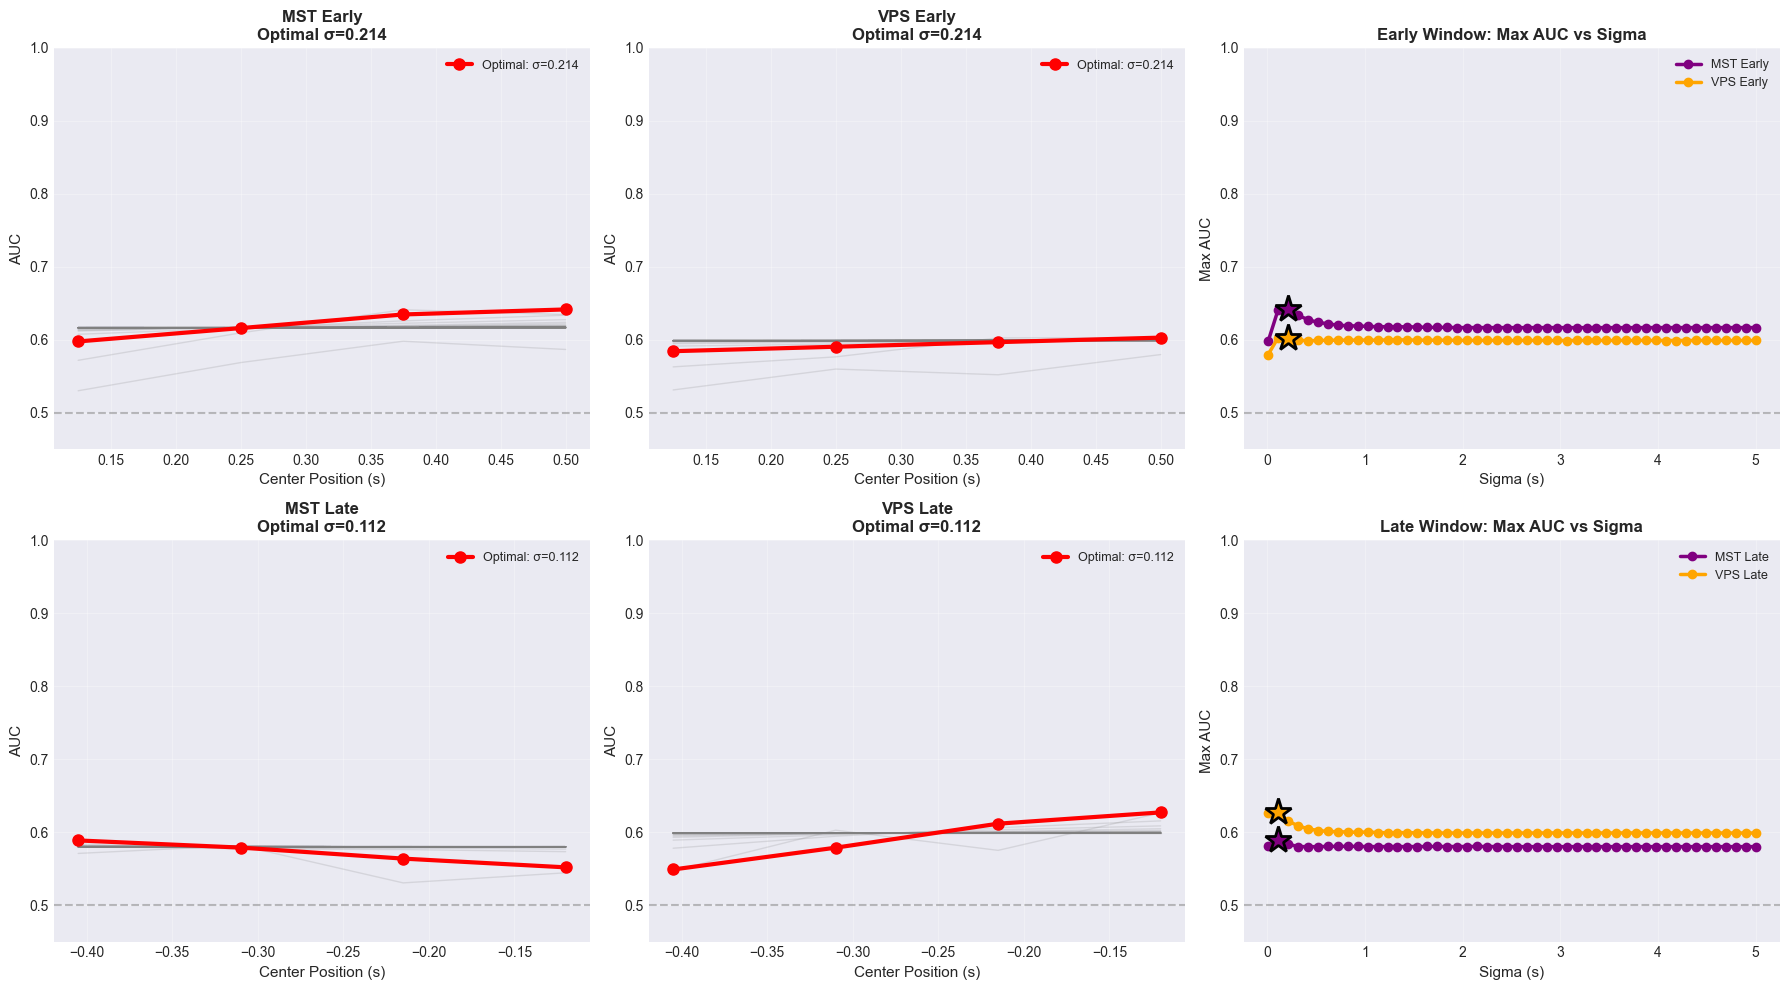


SCANNING TEMPORAL PROFILES WITH OPTIMAL SIGMAS

Optimal sigmas:
  MST Early: 0.214s
  VPS Early: 0.214s
  MST Late:  0.112s
  VPS Late:  0.112s

Scanning early window with 20 centers...

[DEBUG] scan_temporal_profile_with_optimal_sigma called
  dv_mst shape: (276, 51)
  dv_vps shape: (276, 51)
  time_axis shape: (51,)
  time_indices type: <class 'numpy.ndarray'>
  choices shape: (276,)
  sigma_mst: 0.2136734693877551
  sigma_vps: 0.2136734693877551
  n_scan_centers: 20
  window_start: 0.000s
  window_end: 0.500s
  time_windowed length: 26
  center_positions: [1.38777878e-17 2.63157895e-02 5.26315789e-02]...[0.44736842 0.47368421 0.5       ]

[DEBUG] Starting scan loop...
  Processing center 1/20: 0.000s
    int_mst: mean=0.504, std=0.073, shape=(276,)
    int_vps: mean=0.484, std=0.073, shape=(276,)
    Combined AUC: 0.584
    Accuracy: 0.554
    Coef MST: 1.038, Coef VPS: 3.927
  Processing center 6/20: 0.132s
  Processing center 11/20: 0.263s
  Processing center 16/20: 0.395s

[DEBU

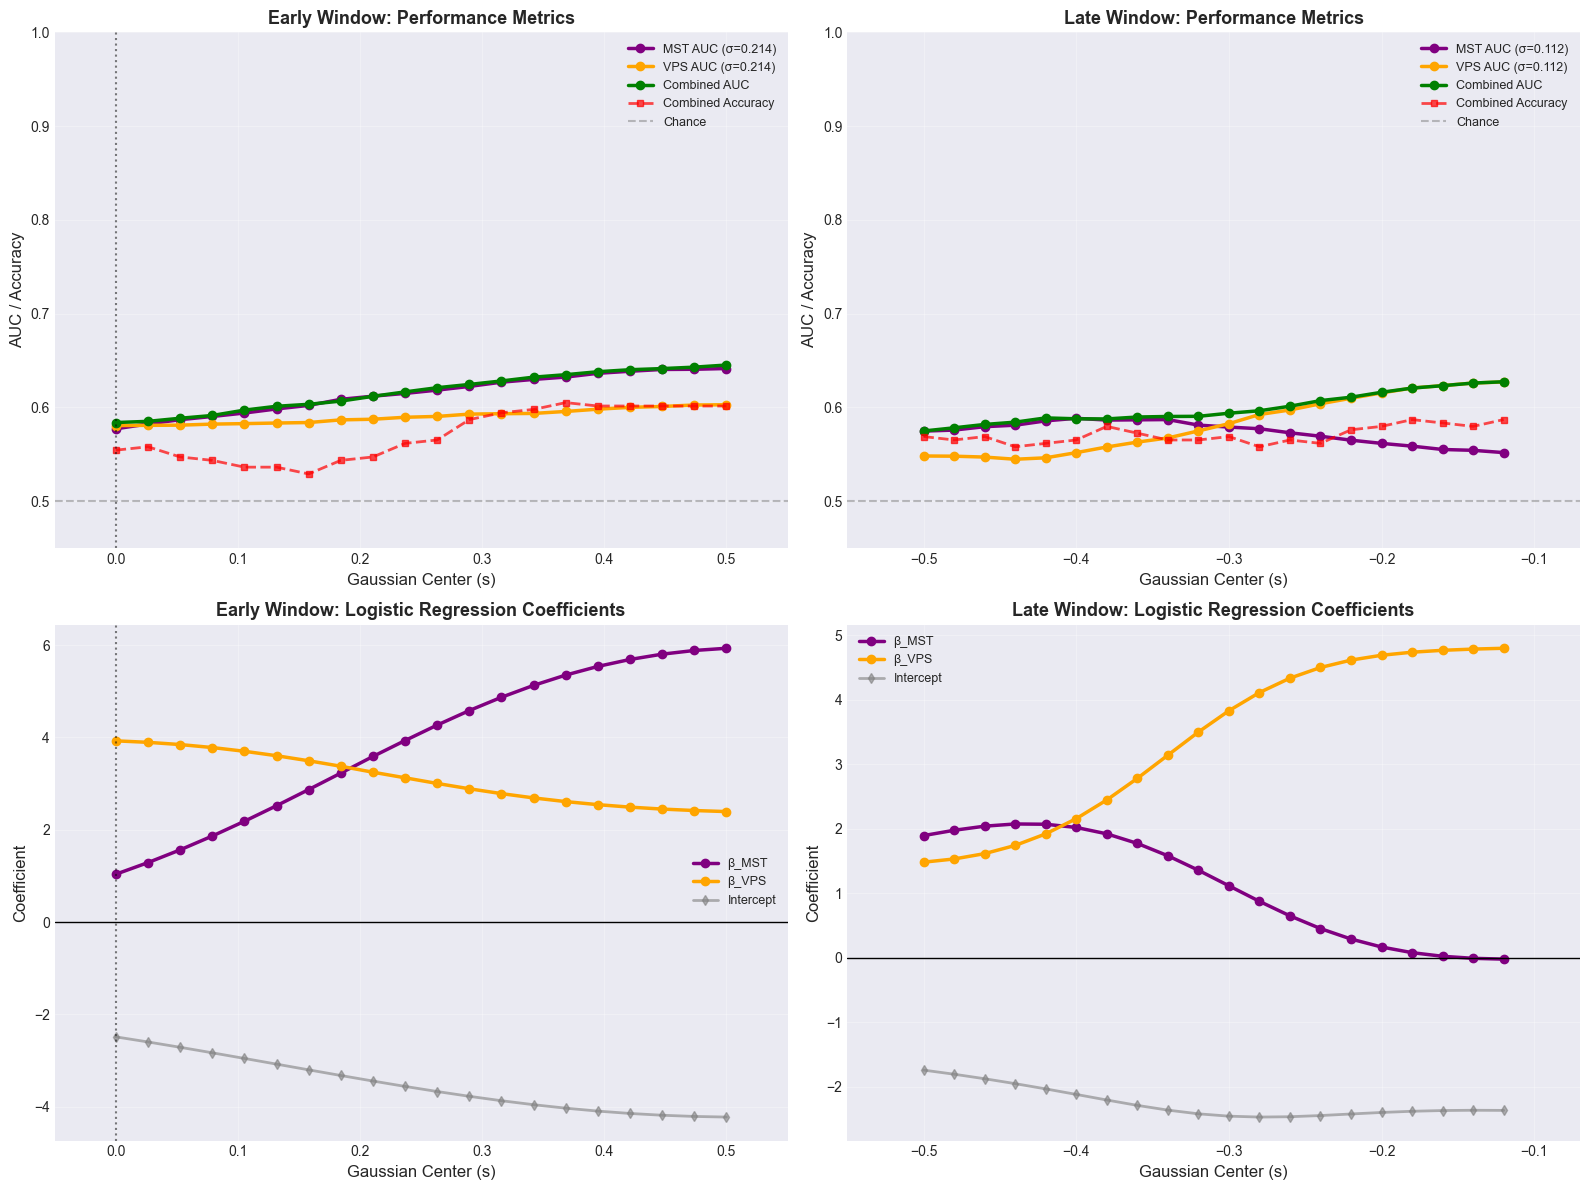


FITTING FINAL MODEL AT OPTIMAL CENTERS

Optimal centers (highest combined AUC):
  Early: 0.500s (AUC=0.645)
  Late:  -0.120s (AUC=0.627)

Integrating DVs with optimal parameters...

Fitting logistic regression...
  Features: MST_early, VPS_early, MST_late, VPS_late
  Samples: 276

Model performance:
  AUC: 0.659
  Accuracy: 0.598

Coefficients:
  MST_early   : +6.4845
  VPS_early   : +1.6824
  MST_late    : -2.5899
  VPS_late    : +2.4404

Bootstrapping (1000 iterations)...

Bootstrap results (95% CI):
  MST_early   : +6.7145 [+2.2804, +11.4141]
  VPS_early   : +1.6916 [-2.5522, +5.9942]
  MST_late    : -2.6599 [-5.9681, +0.7492]
  VPS_late    : +2.5229 [-0.9015, +6.1186]


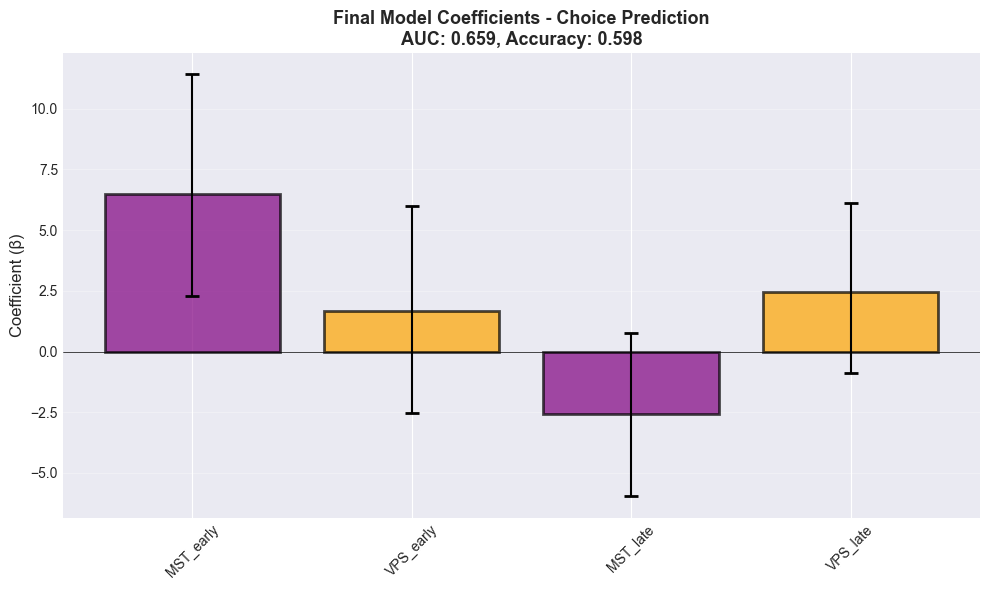


PIPELINE COMPLETE FOR CONDITION: (1, 1)

RUNNING NEW PIPELINE FOR CONDITION: (2, 1)
LOADING DATA FOR CHOICE DECODER
Condition: (2, 1)

Loading MST...
  Early (stimOn): 281 trials, 51 timepoints
  Late (saccOnset): 281 trials, 51 timepoints

Loading VPS...
  Early (stimOn): 281 trials, 51 timepoints
  Late (saccOnset): 281 trials, 51 timepoints

Data loading complete!

MATCHING TRIALS ACROSS AREAS
Matched early trials: 281
Matched late trials: 281

COMPUTING RT-ADAPTIVE TIME WINDOWS

  RT Statistics:
    Min RT:    0.317s
    Max RT:    2.309s
    Median RT: 0.925s
    Mean RT:   0.937s

  Adaptive Windows:
    Early: 0.000 to 0.825s (stimulus-aligned)
    Late:  -0.825 to -0.100s (saccade-aligned)

Time windows:
  Early: 0.000 to 0.825s (stimOn)
  Late: -0.825 to -0.100s (saccOnset)

Time points in windows:
  Early: 42 points
  Late: 25 points

SELECTING OPTIMAL SIGMA VALUES
Testing sigma range: [0.010, 5.000] with 50 values
Testing at 4 center positions per window
Selection criterion

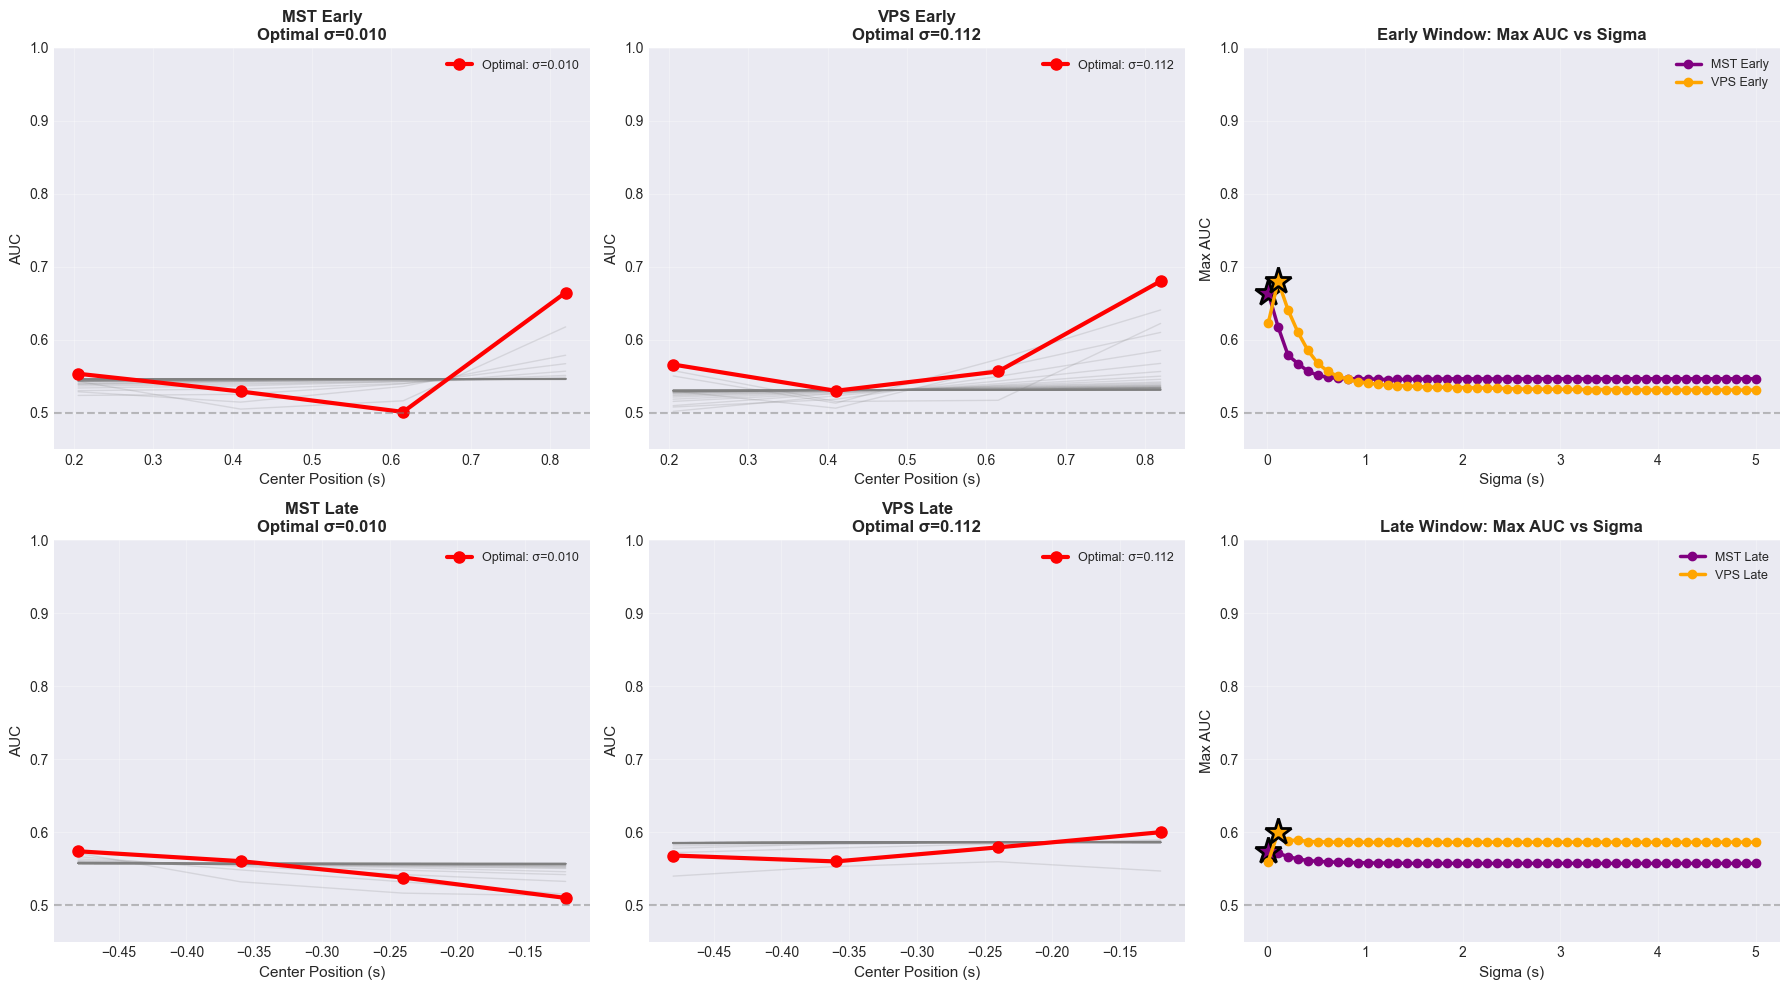


SCANNING TEMPORAL PROFILES WITH OPTIMAL SIGMAS

Optimal sigmas:
  MST Early: 0.010s
  VPS Early: 0.112s
  MST Late:  0.010s
  VPS Late:  0.112s

Scanning early window with 20 centers...

[DEBUG] scan_temporal_profile_with_optimal_sigma called
  dv_mst shape: (281, 51)
  dv_vps shape: (281, 51)
  time_axis shape: (51,)
  time_indices type: <class 'numpy.ndarray'>
  choices shape: (281,)
  sigma_mst: 0.01
  sigma_vps: 0.11183673469387755
  n_scan_centers: 20
  window_start: 0.000s
  window_end: 0.820s
  time_windowed length: 42
  center_positions: [1.38777878e-17 4.31578947e-02 8.63157895e-02]...[0.73368421 0.77684211 0.82      ]

[DEBUG] Starting scan loop...
  Processing center 1/20: 0.000s
    int_mst: mean=0.542, std=0.142, shape=(281,)
    int_vps: mean=0.512, std=0.073, shape=(281,)
    Combined AUC: 0.532
    Accuracy: 0.537
    Coef MST: 0.484, Coef VPS: -1.046
  Processing center 6/20: 0.216s
  Processing center 11/20: 0.432s
  Processing center 16/20: 0.647s

[DEBUG] Scan comp

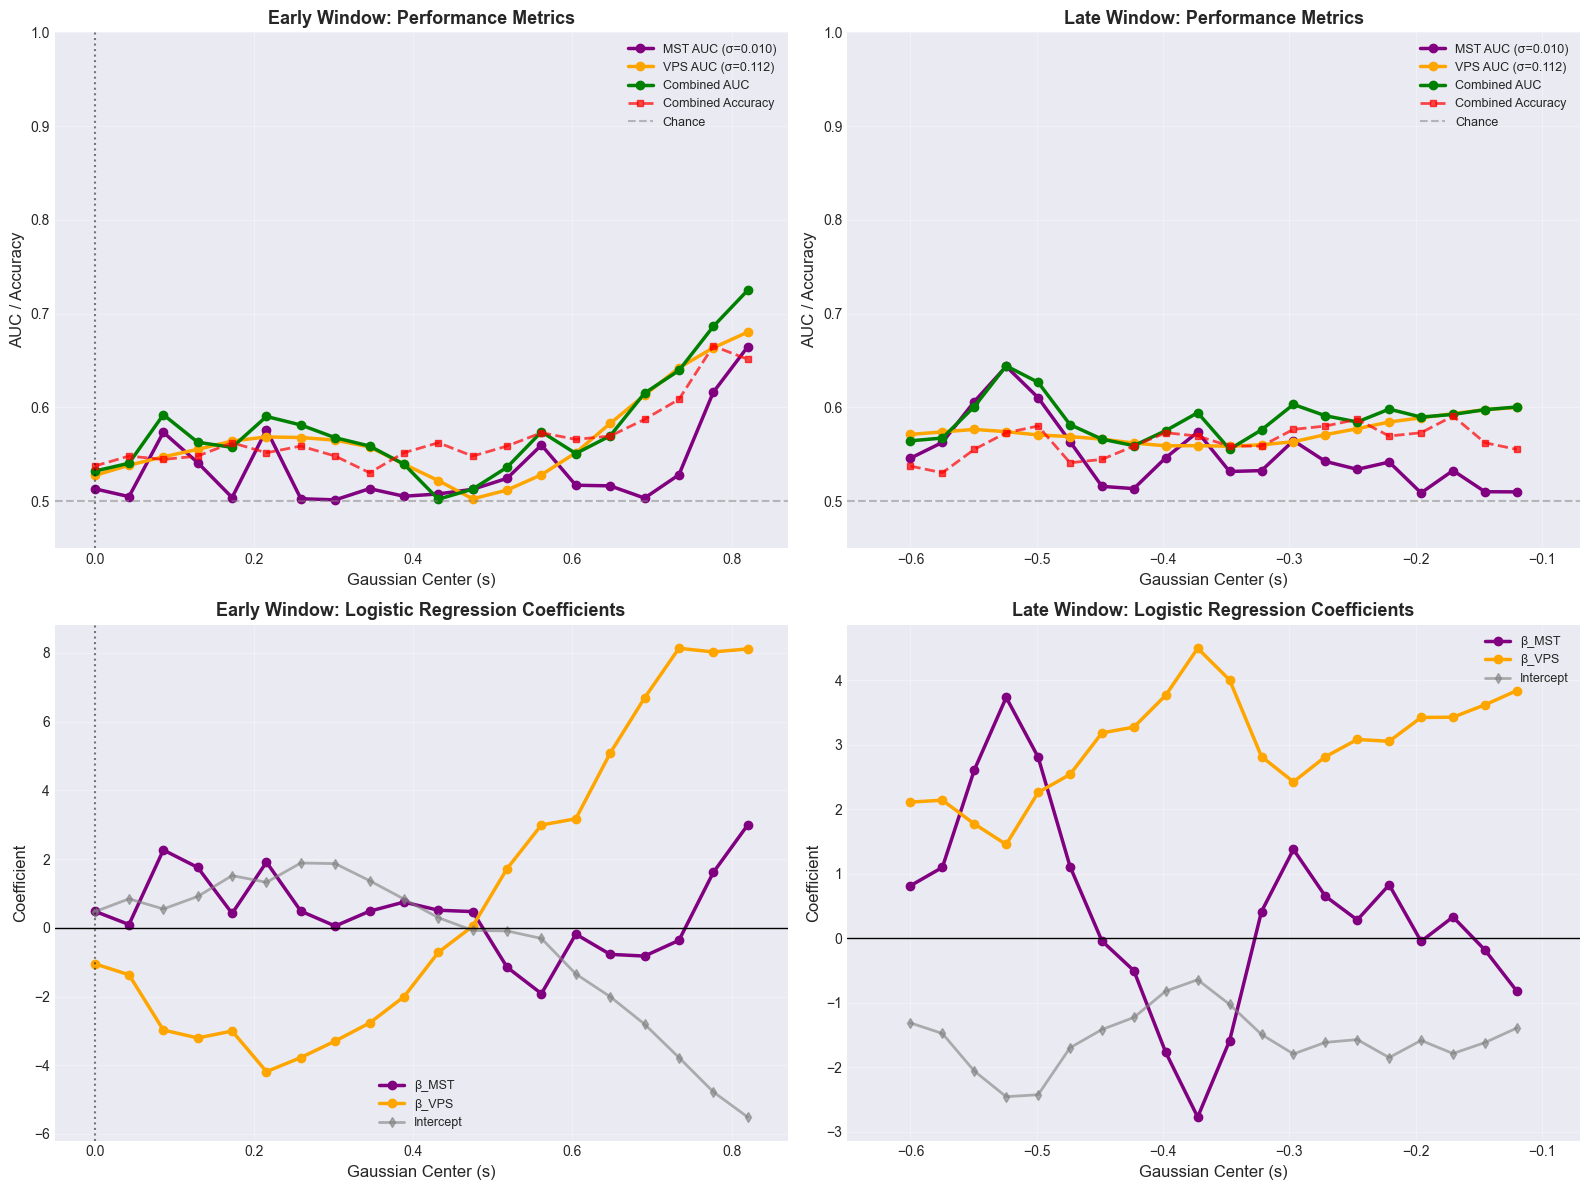


FITTING FINAL MODEL AT OPTIMAL CENTERS

Optimal centers (highest combined AUC):
  Early: 0.820s (AUC=0.725)
  Late:  -0.524s (AUC=0.644)

Integrating DVs with optimal parameters...

Fitting logistic regression...
  Features: MST_early, VPS_early, MST_late, VPS_late
  Samples: 281

Model performance:
  AUC: 0.729
  Accuracy: 0.662

Coefficients:
  MST_early   : +2.7786
  VPS_early   : +7.3765
  MST_late    : +2.6749
  VPS_late    : -0.9270

Bootstrapping (1000 iterations)...

Bootstrap results (95% CI):
  MST_early   : +2.8371 [+1.1890, +4.7374]
  VPS_early   : +7.5968 [+3.6592, +11.9811]
  MST_late    : +2.7801 [+0.7081, +5.0324]
  VPS_late    : -1.0602 [-4.6652, +2.5599]


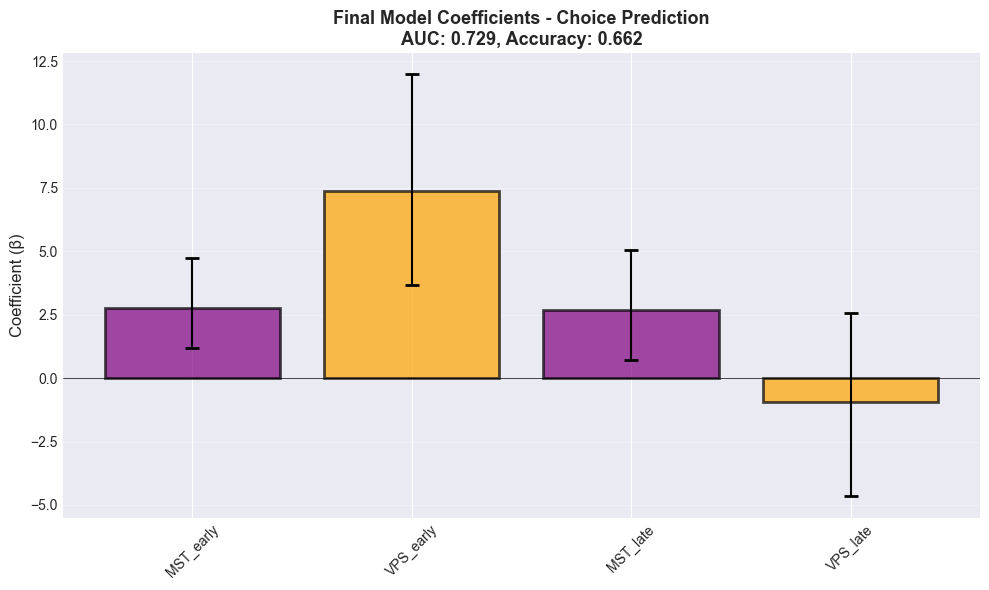


PIPELINE COMPLETE FOR CONDITION: (2, 1)

RUNNING NEW PIPELINE FOR CONDITION: (2, 2)
LOADING DATA FOR CHOICE DECODER
Condition: (2, 2)

Loading MST...
  Early (stimOn): 283 trials, 51 timepoints
  Late (saccOnset): 283 trials, 51 timepoints

Loading VPS...
  Early (stimOn): 283 trials, 51 timepoints
  Late (saccOnset): 283 trials, 51 timepoints

Data loading complete!

MATCHING TRIALS ACROSS AREAS
Matched early trials: 283
Matched late trials: 283

COMPUTING RT-ADAPTIVE TIME WINDOWS

  RT Statistics:
    Min RT:    0.275s
    Max RT:    1.450s
    Median RT: 0.759s
    Mean RT:   0.780s

  Adaptive Windows:
    Early: 0.000 to 0.659s (stimulus-aligned)
    Late:  -0.659 to -0.100s (saccade-aligned)

Time windows:
  Early: 0.000 to 0.659s (stimOn)
  Late: -0.659 to -0.100s (saccOnset)

Time points in windows:
  Early: 33 points
  Late: 25 points

SELECTING OPTIMAL SIGMA VALUES
Testing sigma range: [0.010, 5.000] with 50 values
Testing at 4 center positions per window
Selection criterion

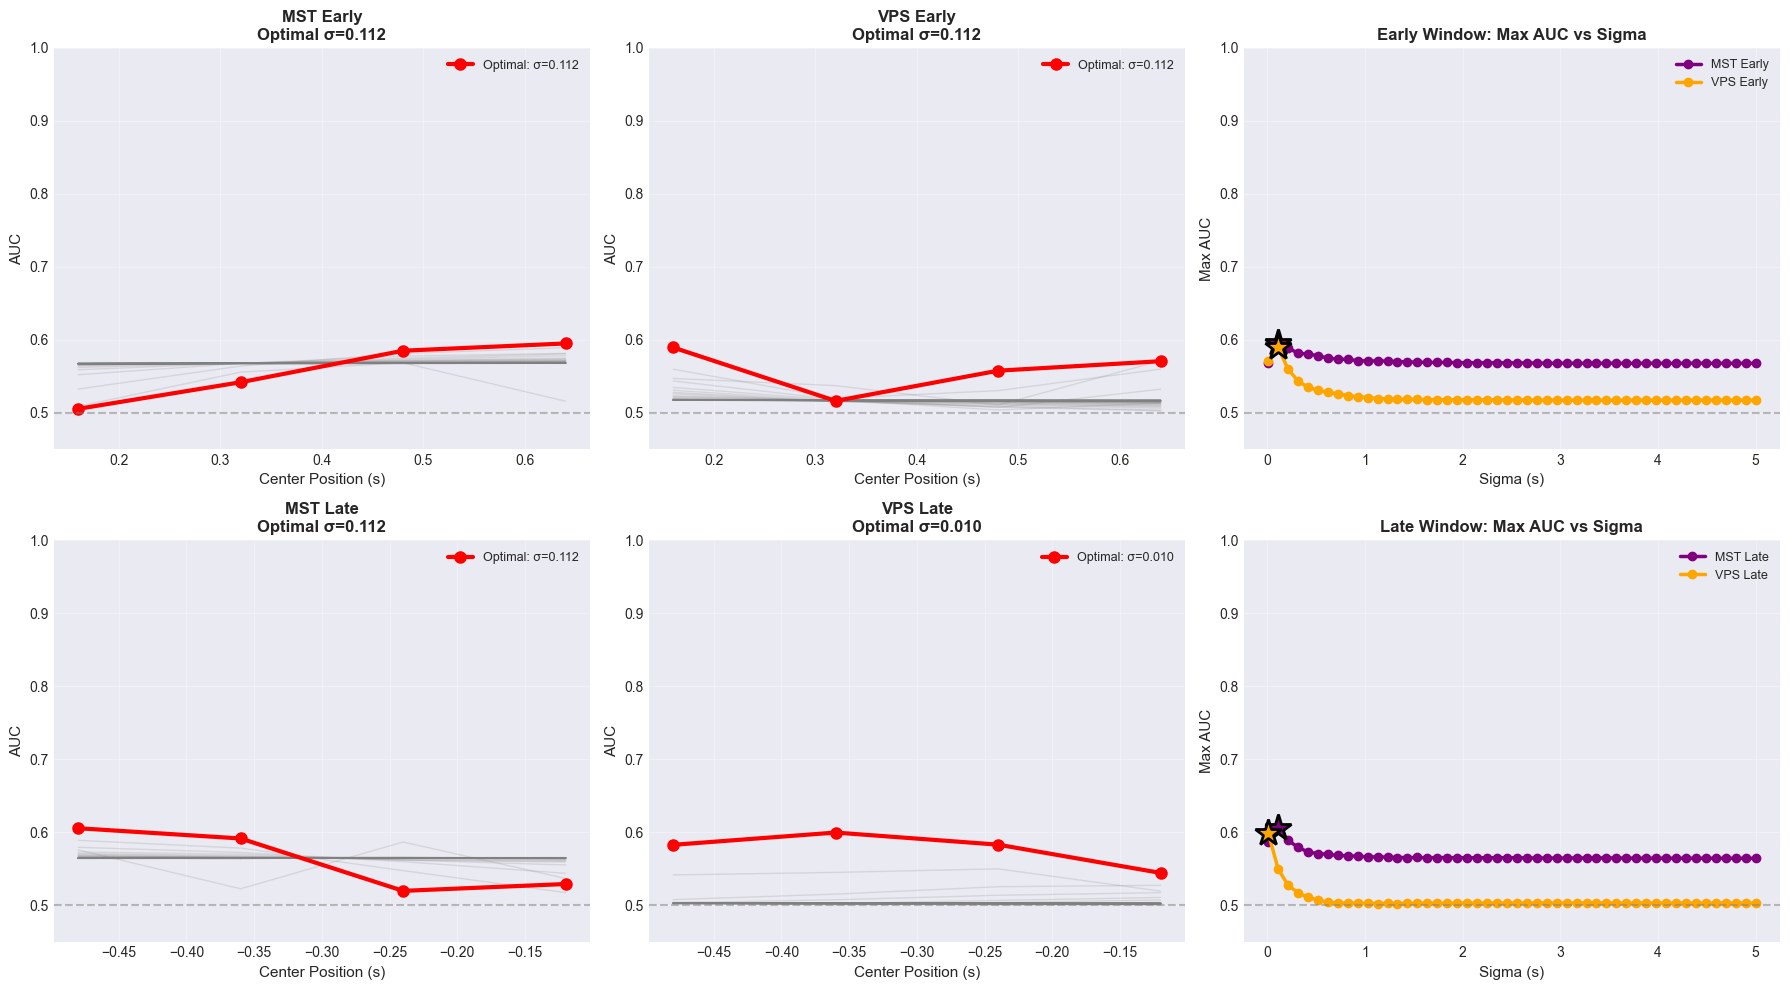


SCANNING TEMPORAL PROFILES WITH OPTIMAL SIGMAS

Optimal sigmas:
  MST Early: 0.112s
  VPS Early: 0.112s
  MST Late:  0.112s
  VPS Late:  0.010s

Scanning early window with 20 centers...

[DEBUG] scan_temporal_profile_with_optimal_sigma called
  dv_mst shape: (283, 51)
  dv_vps shape: (283, 51)
  time_axis shape: (51,)
  time_indices type: <class 'numpy.ndarray'>
  choices shape: (283,)
  sigma_mst: 0.11183673469387755
  sigma_vps: 0.11183673469387755
  n_scan_centers: 20
  window_start: 0.000s
  window_end: 0.640s
  time_windowed length: 33
  center_positions: [1.38777878e-17 3.36842105e-02 6.73684211e-02]...[0.57263158 0.60631579 0.64      ]

[DEBUG] Starting scan loop...
  Processing center 1/20: 0.000s
    int_mst: mean=0.506, std=0.066, shape=(283,)
    int_vps: mean=0.509, std=0.051, shape=(283,)
    Combined AUC: 0.607
    Accuracy: 0.558
    Coef MST: 0.275, Coef VPS: -9.701
  Processing center 6/20: 0.168s
  Processing center 11/20: 0.337s
  Processing center 16/20: 0.505s

[D

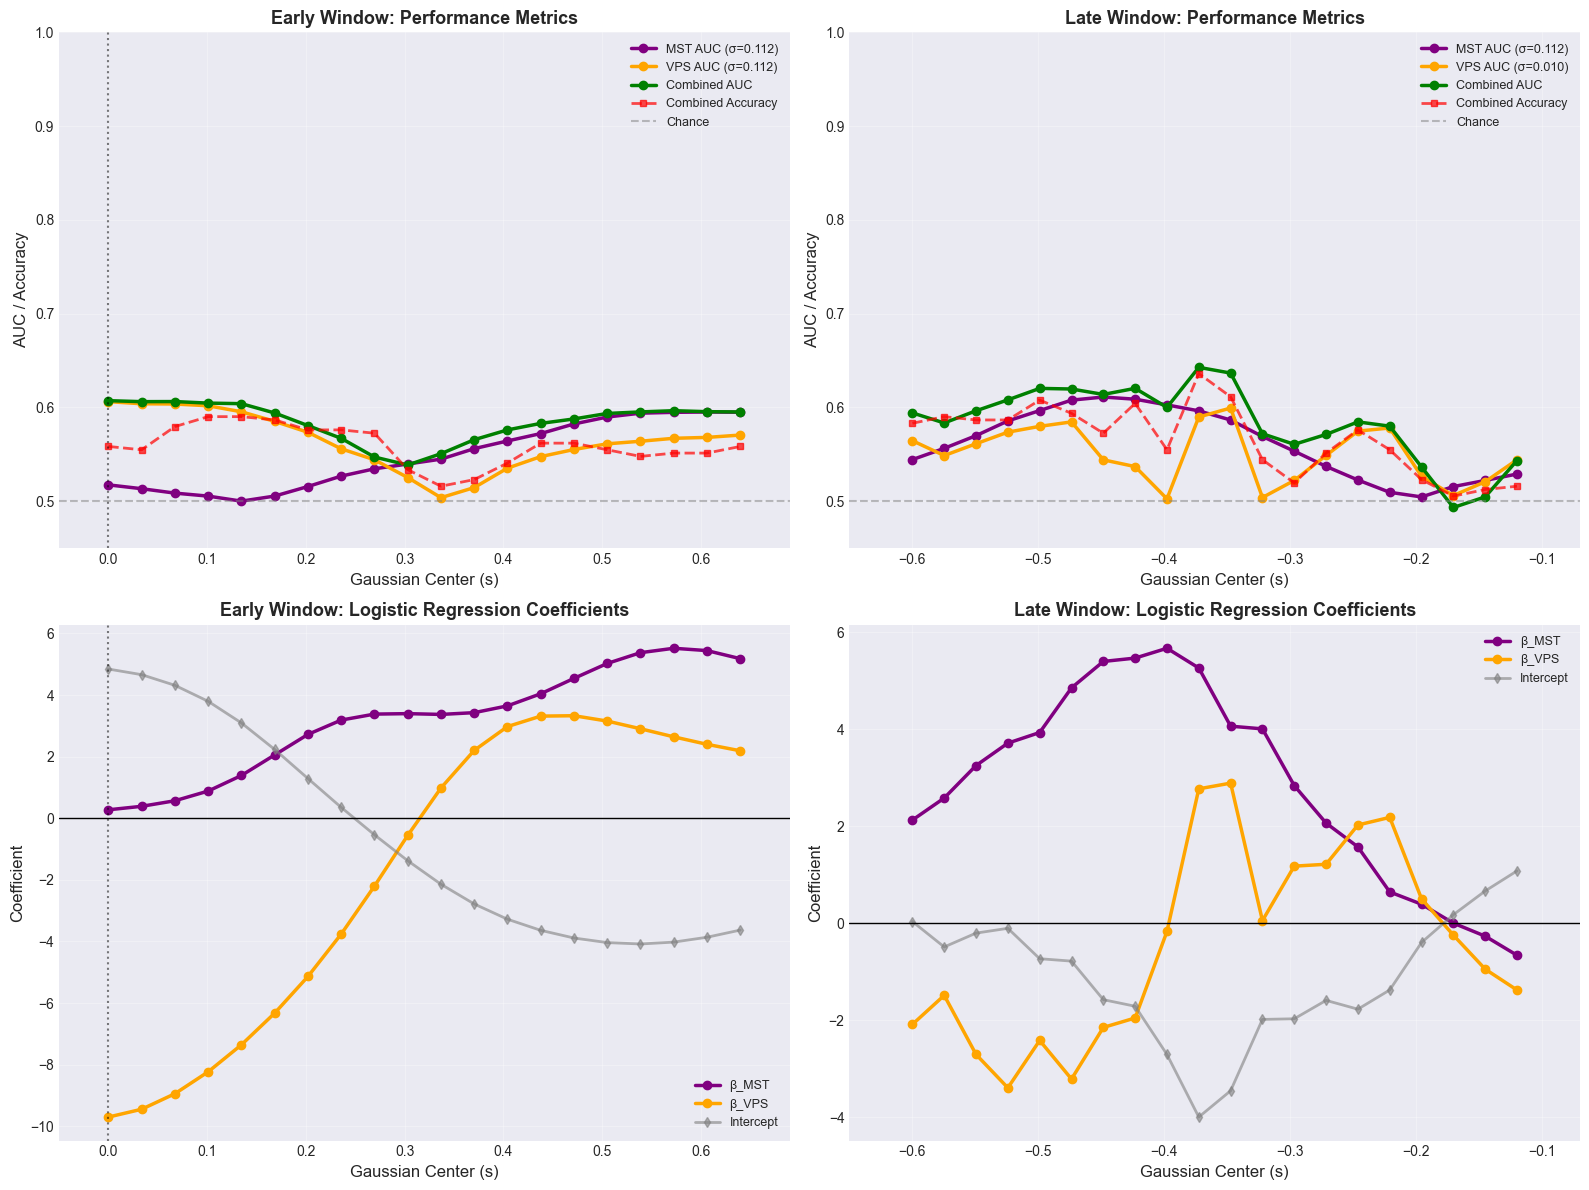


FITTING FINAL MODEL AT OPTIMAL CENTERS

Optimal centers (highest combined AUC):
  Early: 0.000s (AUC=0.607)
  Late:  -0.373s (AUC=0.643)

Integrating DVs with optimal parameters...

Fitting logistic regression...
  Features: MST_early, VPS_early, MST_late, VPS_late
  Samples: 283

Model performance:
  AUC: 0.695
  Accuracy: 0.647

Coefficients:
  MST_early   : -1.6353
  VPS_early   : -10.5843
  MST_late    : +7.1350
  VPS_late    : +3.0351

Bootstrapping (1000 iterations)...

Bootstrap results (95% CI):
  MST_early   : -1.7473 [-6.0159, +2.4066]
  VPS_early   : -10.9987 [-17.5691, -4.9493]
  MST_late    : +7.4603 [+2.1025, +13.7843]
  VPS_late    : +3.1414 [+0.8729, +5.5318]


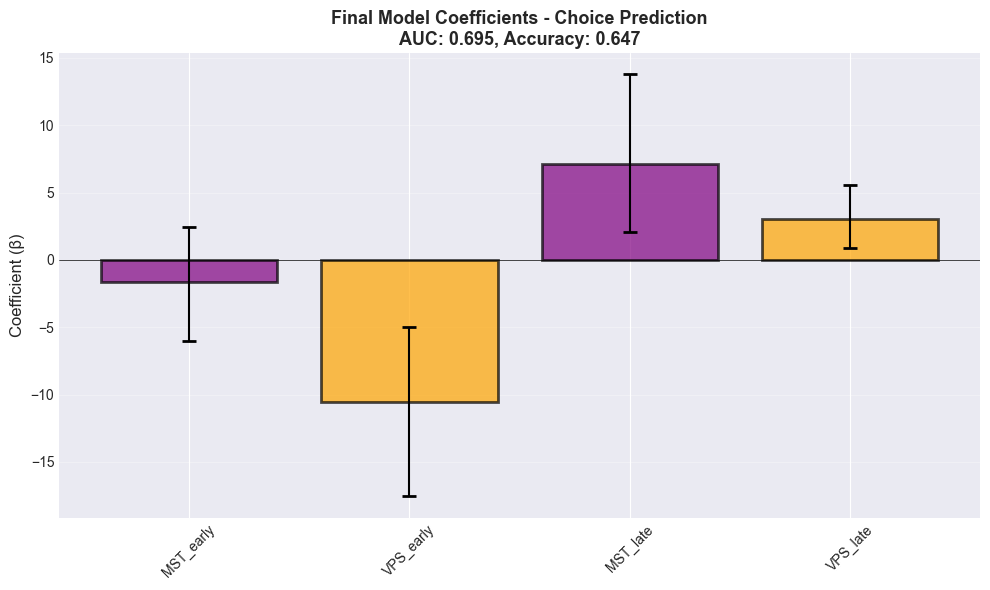


PIPELINE COMPLETE FOR CONDITION: (2, 2)

RUNNING NEW PIPELINE FOR CONDITION: (3, 1)
LOADING DATA FOR CHOICE DECODER
Condition: (3, 1)

Loading MST...
  Early (stimOn): 283 trials, 51 timepoints
  Late (saccOnset): 283 trials, 51 timepoints

Loading VPS...
  Early (stimOn): 283 trials, 51 timepoints
  Late (saccOnset): 283 trials, 51 timepoints

Data loading complete!

MATCHING TRIALS ACROSS AREAS
Matched early trials: 283
Matched late trials: 283

COMPUTING RT-ADAPTIVE TIME WINDOWS

  RT Statistics:
    Min RT:    0.267s
    Max RT:    1.467s
    Median RT: 0.700s
    Mean RT:   0.731s

  Adaptive Windows:
    Early: 0.000 to 0.600s (stimulus-aligned)
    Late:  -0.600 to -0.100s (saccade-aligned)

Time windows:
  Early: 0.000 to 0.600s (stimOn)
  Late: -0.600 to -0.100s (saccOnset)

Time points in windows:
  Early: 31 points
  Late: 25 points

SELECTING OPTIMAL SIGMA VALUES
Testing sigma range: [0.010, 5.000] with 50 values
Testing at 4 center positions per window
Selection criterion

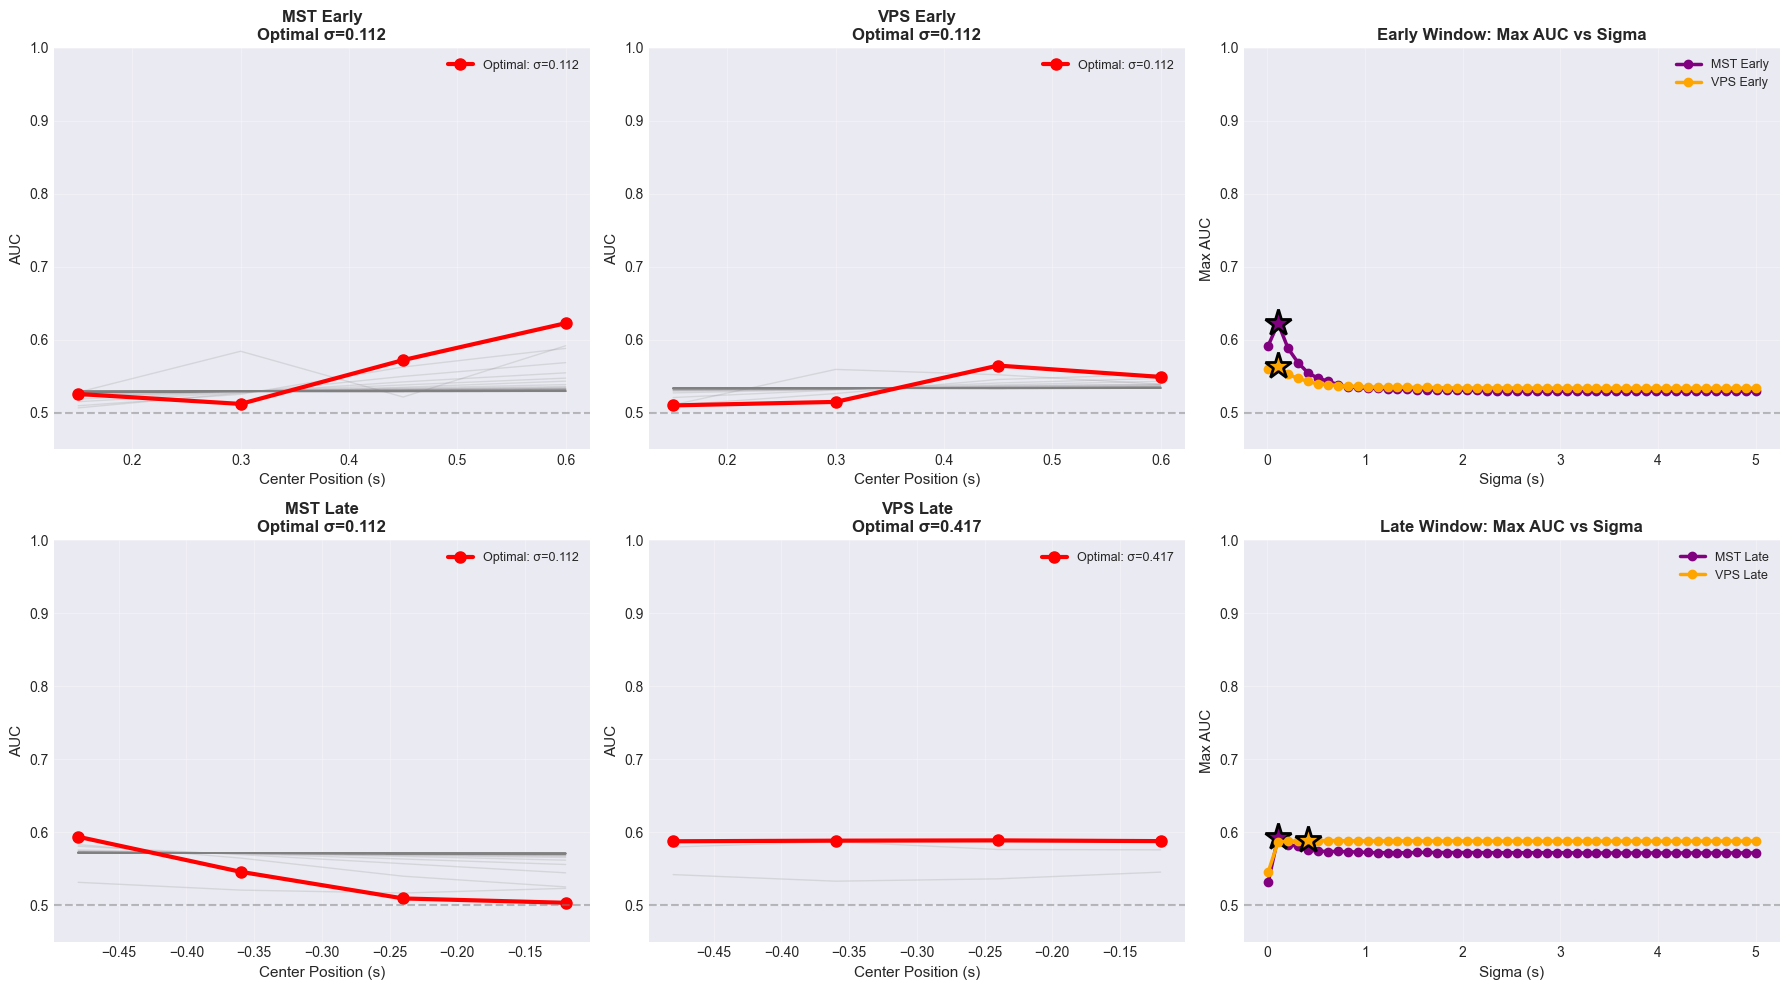


SCANNING TEMPORAL PROFILES WITH OPTIMAL SIGMAS

Optimal sigmas:
  MST Early: 0.112s
  VPS Early: 0.112s
  MST Late:  0.112s
  VPS Late:  0.417s

Scanning early window with 20 centers...

[DEBUG] scan_temporal_profile_with_optimal_sigma called
  dv_mst shape: (283, 51)
  dv_vps shape: (283, 51)
  time_axis shape: (51,)
  time_indices type: <class 'numpy.ndarray'>
  choices shape: (283,)
  sigma_mst: 0.11183673469387755
  sigma_vps: 0.11183673469387755
  n_scan_centers: 20
  window_start: 0.000s
  window_end: 0.600s
  time_windowed length: 31
  center_positions: [1.38777878e-17 3.15789474e-02 6.31578947e-02]...[0.53684211 0.56842105 0.6       ]

[DEBUG] Starting scan loop...
  Processing center 1/20: 0.000s
    int_mst: mean=0.532, std=0.088, shape=(283,)
    int_vps: mean=0.526, std=0.091, shape=(283,)
    Combined AUC: 0.543
    Accuracy: 0.601
    Coef MST: -1.698, Coef VPS: 0.026
  Processing center 6/20: 0.158s
  Processing center 11/20: 0.316s
  Processing center 16/20: 0.474s

[D

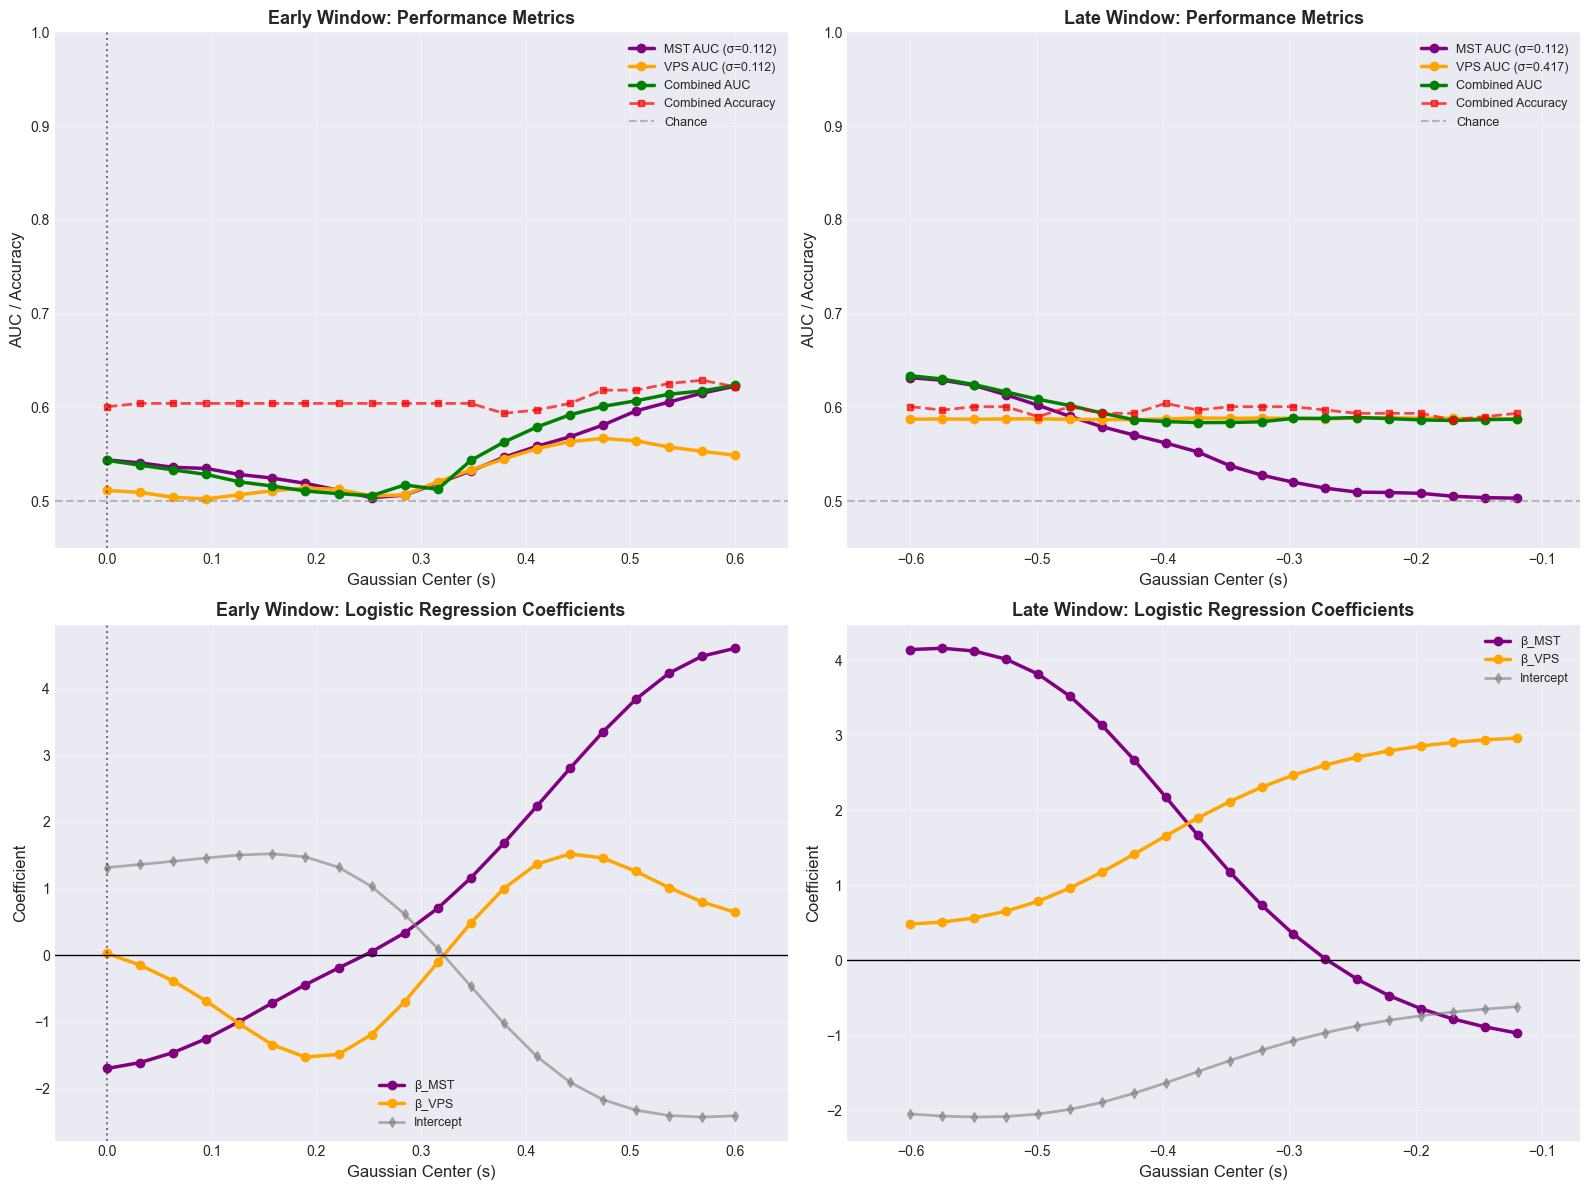


FITTING FINAL MODEL AT OPTIMAL CENTERS

Optimal centers (highest combined AUC):
  Early: 0.600s (AUC=0.623)
  Late:  -0.600s (AUC=0.634)

Integrating DVs with optimal parameters...

Fitting logistic regression...
  Features: MST_early, VPS_early, MST_late, VPS_late
  Samples: 283

Model performance:
  AUC: 0.646
  Accuracy: 0.625

Coefficients:
  MST_early   : +3.6439
  VPS_early   : +0.4716
  MST_late    : +3.4849
  VPS_late    : -0.8776

Bootstrapping (1000 iterations)...

Bootstrap results (95% CI):
  MST_early   : +3.7262 [+0.4335, +6.6351]
  VPS_early   : +0.3607 [-2.7475, +3.3009]
  MST_late    : +3.6660 [+1.0239, +6.5724]
  VPS_late    : -0.7637 [-4.7140, +3.3328]


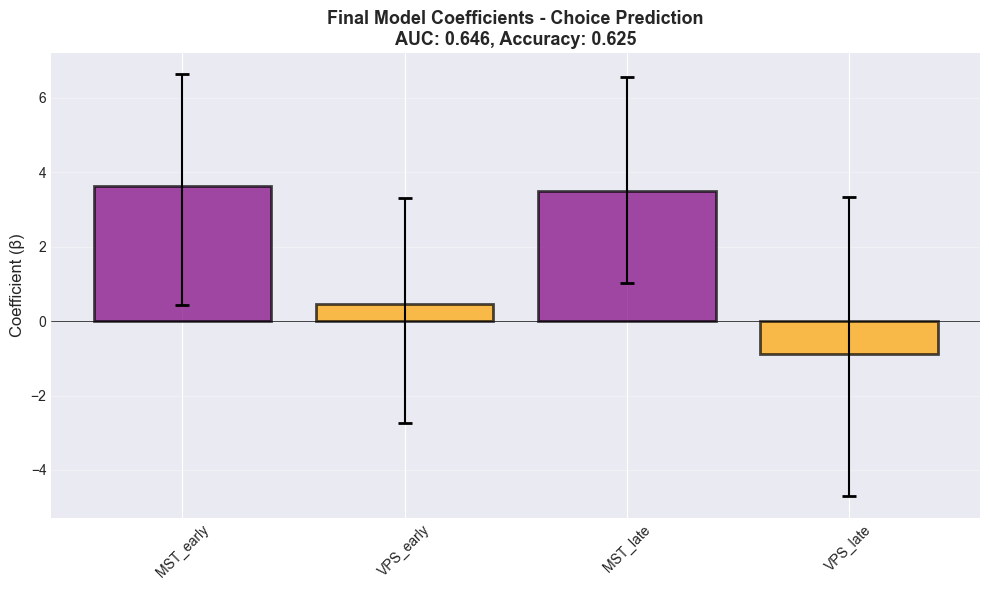


PIPELINE COMPLETE FOR CONDITION: (3, 1)

RUNNING NEW PIPELINE FOR CONDITION: (3, 2)
LOADING DATA FOR CHOICE DECODER
Condition: (3, 2)

Loading MST...
  Early (stimOn): 280 trials, 51 timepoints
  Late (saccOnset): 280 trials, 51 timepoints

Loading VPS...
  Early (stimOn): 280 trials, 51 timepoints
  Late (saccOnset): 280 trials, 51 timepoints

Data loading complete!

MATCHING TRIALS ACROSS AREAS
Matched early trials: 280
Matched late trials: 280

COMPUTING RT-ADAPTIVE TIME WINDOWS

  RT Statistics:
    Min RT:    0.275s
    Max RT:    1.242s
    Median RT: 0.675s
    Mean RT:   0.697s

  Adaptive Windows:
    Early: 0.000 to 0.575s (stimulus-aligned)
    Late:  -0.575 to -0.100s (saccade-aligned)

Time windows:
  Early: 0.000 to 0.575s (stimOn)
  Late: -0.575 to -0.100s (saccOnset)

Time points in windows:
  Early: 29 points
  Late: 23 points

SELECTING OPTIMAL SIGMA VALUES
Testing sigma range: [0.010, 5.000] with 50 values
Testing at 4 center positions per window
Selection criterion

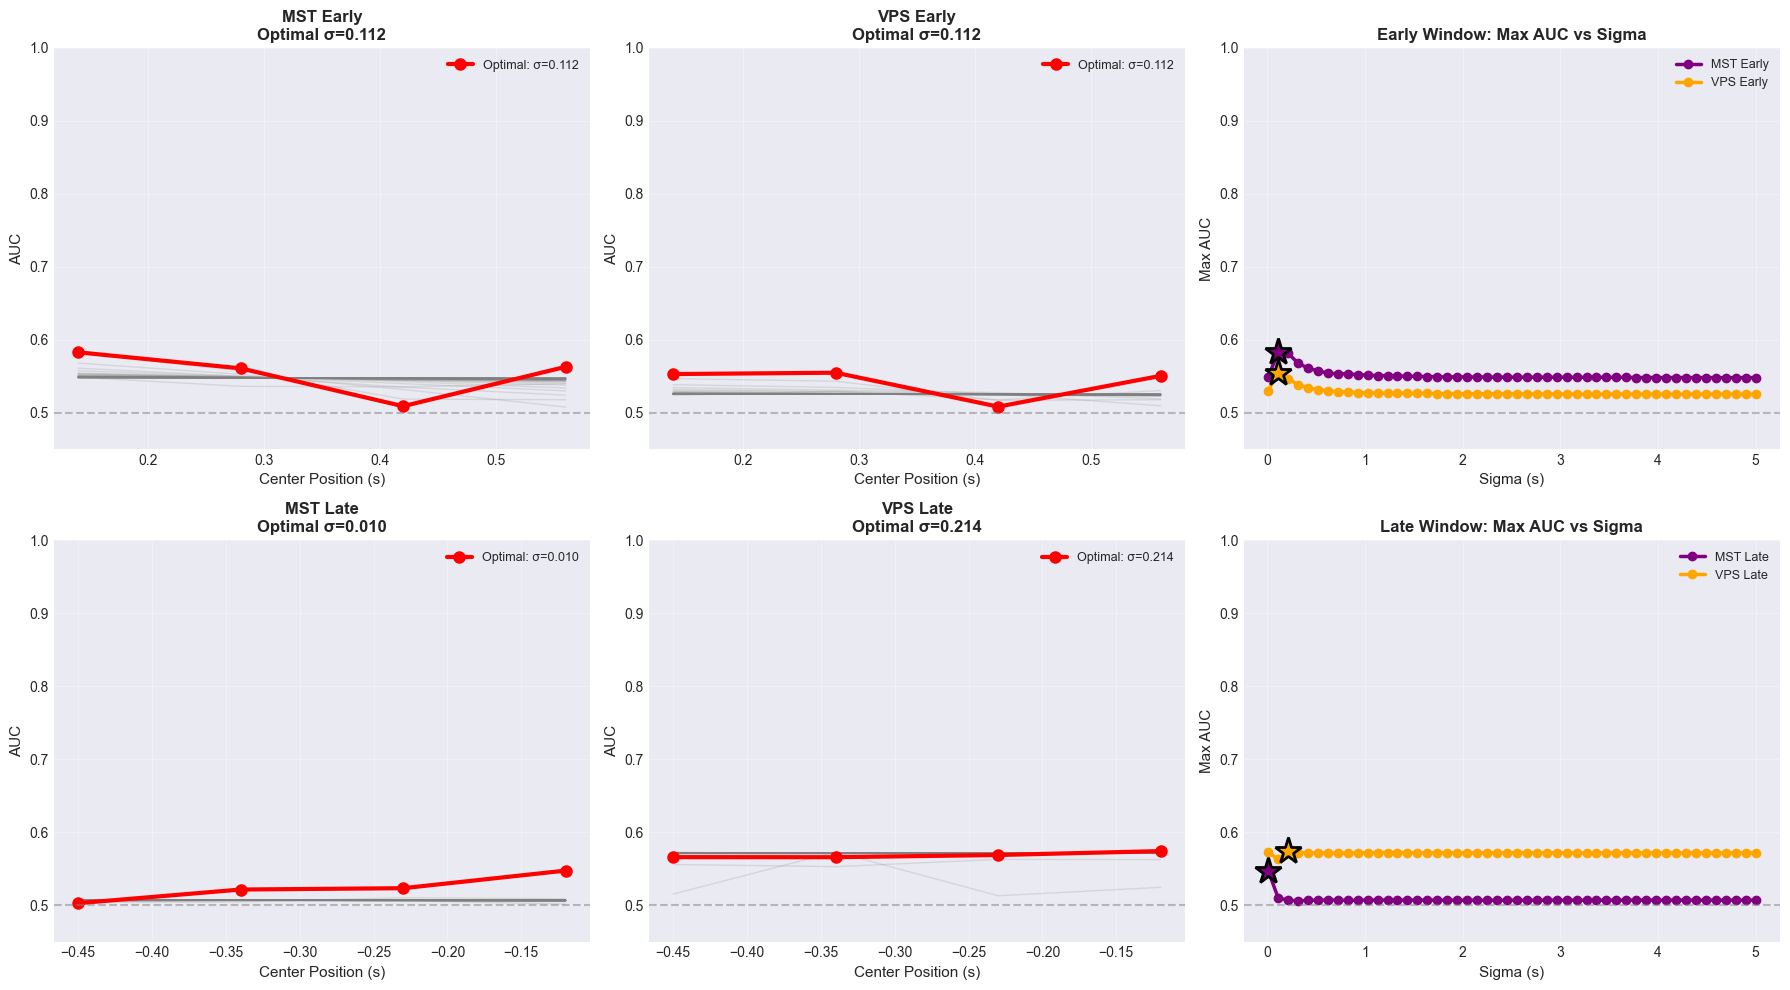


SCANNING TEMPORAL PROFILES WITH OPTIMAL SIGMAS

Optimal sigmas:
  MST Early: 0.112s
  VPS Early: 0.112s
  MST Late:  0.010s
  VPS Late:  0.214s

Scanning early window with 20 centers...

[DEBUG] scan_temporal_profile_with_optimal_sigma called
  dv_mst shape: (280, 51)
  dv_vps shape: (280, 51)
  time_axis shape: (51,)
  time_indices type: <class 'numpy.ndarray'>
  choices shape: (280,)
  sigma_mst: 0.11183673469387755
  sigma_vps: 0.11183673469387755
  n_scan_centers: 20
  window_start: 0.000s
  window_end: 0.560s
  time_windowed length: 29
  center_positions: [1.38777878e-17 2.94736842e-02 5.89473684e-02]...[0.50105263 0.53052632 0.56      ]

[DEBUG] Starting scan loop...
  Processing center 1/20: 0.000s
    int_mst: mean=0.512, std=0.059, shape=(280,)
    int_vps: mean=0.502, std=0.071, shape=(280,)
    Combined AUC: 0.580
    Accuracy: 0.550
    Coef MST: -3.493, Coef VPS: -1.290
  Processing center 6/20: 0.147s
  Processing center 11/20: 0.295s
  Processing center 16/20: 0.442s

[

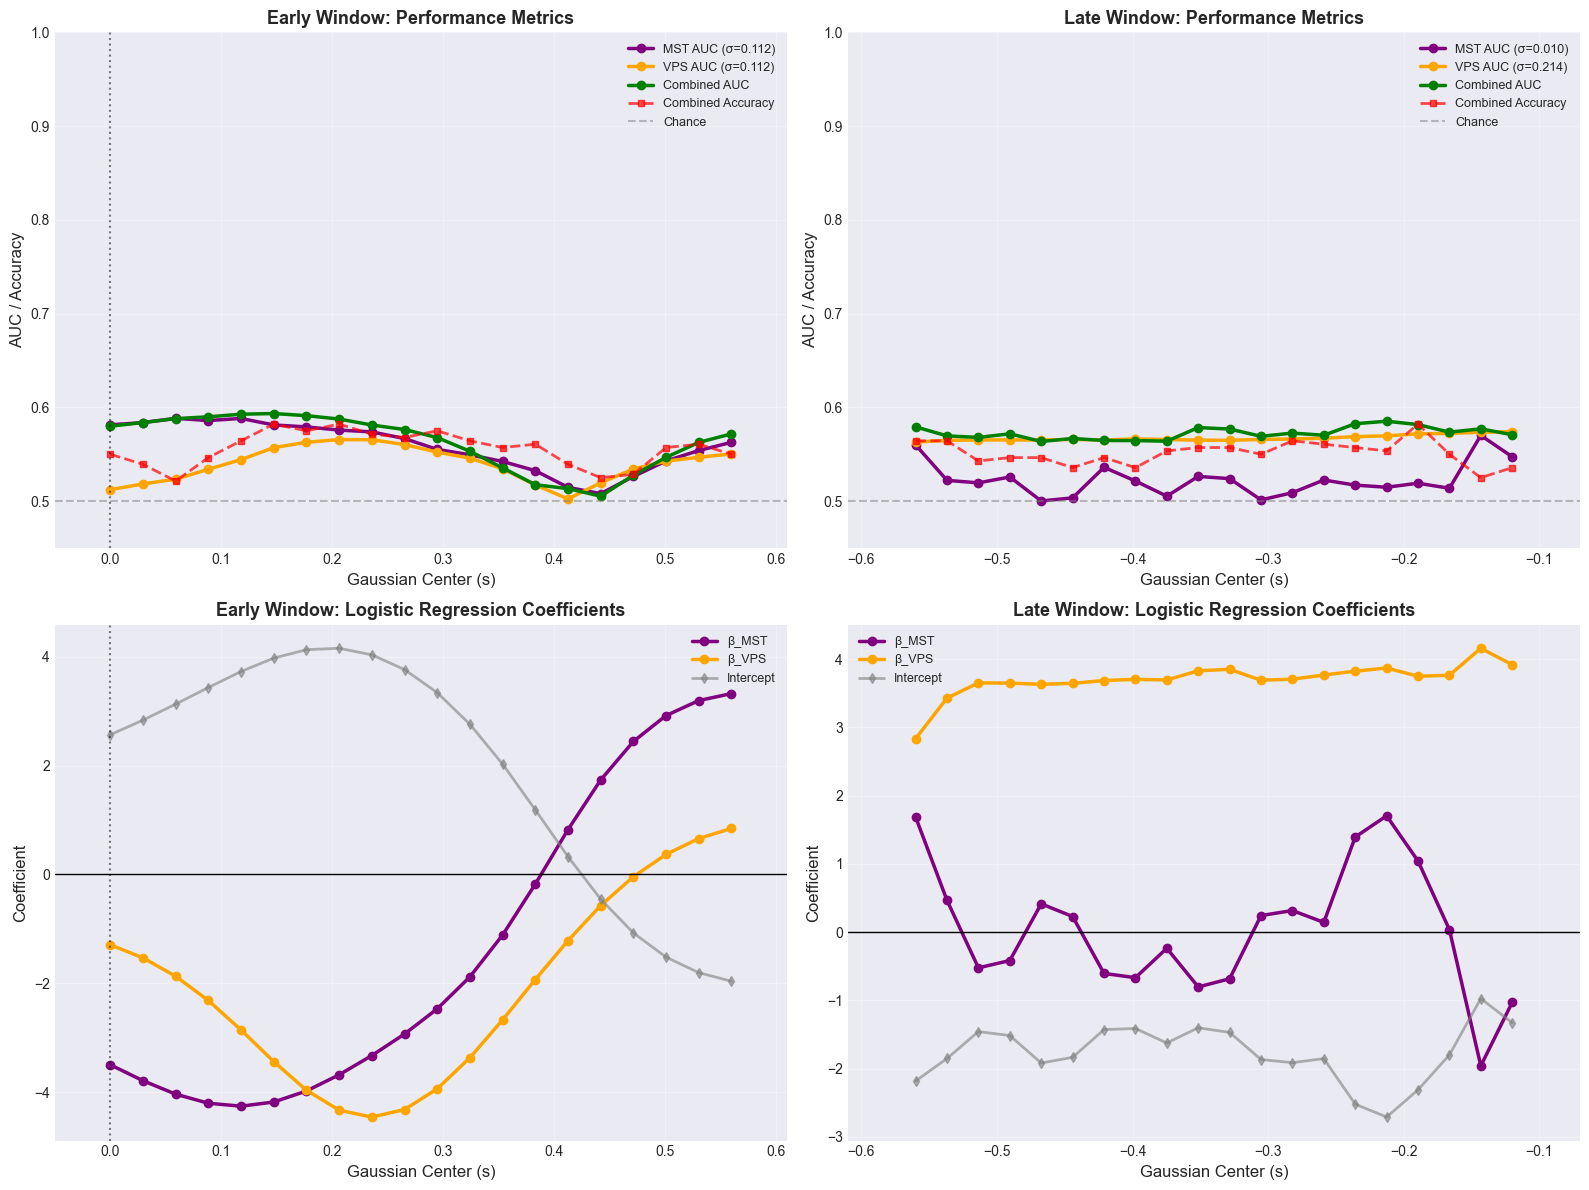


FITTING FINAL MODEL AT OPTIMAL CENTERS

Optimal centers (highest combined AUC):
  Early: 0.147s (AUC=0.593)
  Late:  -0.213s (AUC=0.585)

Integrating DVs with optimal parameters...

Fitting logistic regression...
  Features: MST_early, VPS_early, MST_late, VPS_late
  Samples: 280

Model performance:
  AUC: 0.643
  Accuracy: 0.621

Coefficients:
  MST_early   : -5.2003
  VPS_early   : -5.7816
  MST_late    : +2.0327
  VPS_late    : +6.8015

Bootstrapping (1000 iterations)...

Bootstrap results (95% CI):
  MST_early   : -5.3412 [-11.0421, +0.0166]
  VPS_early   : -6.0201 [-11.1354, -1.4785]
  MST_late    : +2.1600 [-0.0965, +4.2551]
  VPS_late    : +7.1234 [+2.1426, +13.4881]


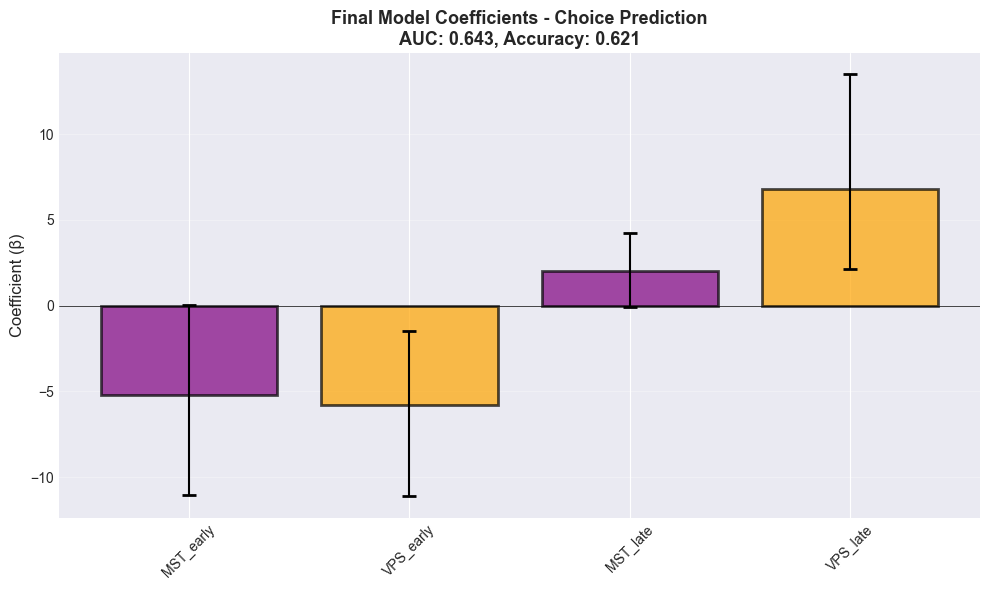


PIPELINE COMPLETE FOR CONDITION: (3, 2)

SUMMARY TABLE: RESULTS ACROSS ALL CONDITIONS
Condition         N    AUC  σ_MST_E  σ_VPS_E 
 σ_MST_L  σ_VPS_L  Center_E  Center_L
----------------------------------------------------------------------------------------------------
(1,1)           276  0.659    0.214    0.214    0.112    0.112     0.500    -0.120
(2,1)           281  0.729    0.010    0.112    0.010    0.112     0.820    -0.524
(2,2)           283  0.695    0.112    0.112    0.112    0.010     0.000    -0.373
(3,1)           283  0.646    0.112    0.112    0.112    0.417     0.600    -0.600
(3,2)           280  0.643    0.112    0.112    0.010    0.214     0.147    -0.213


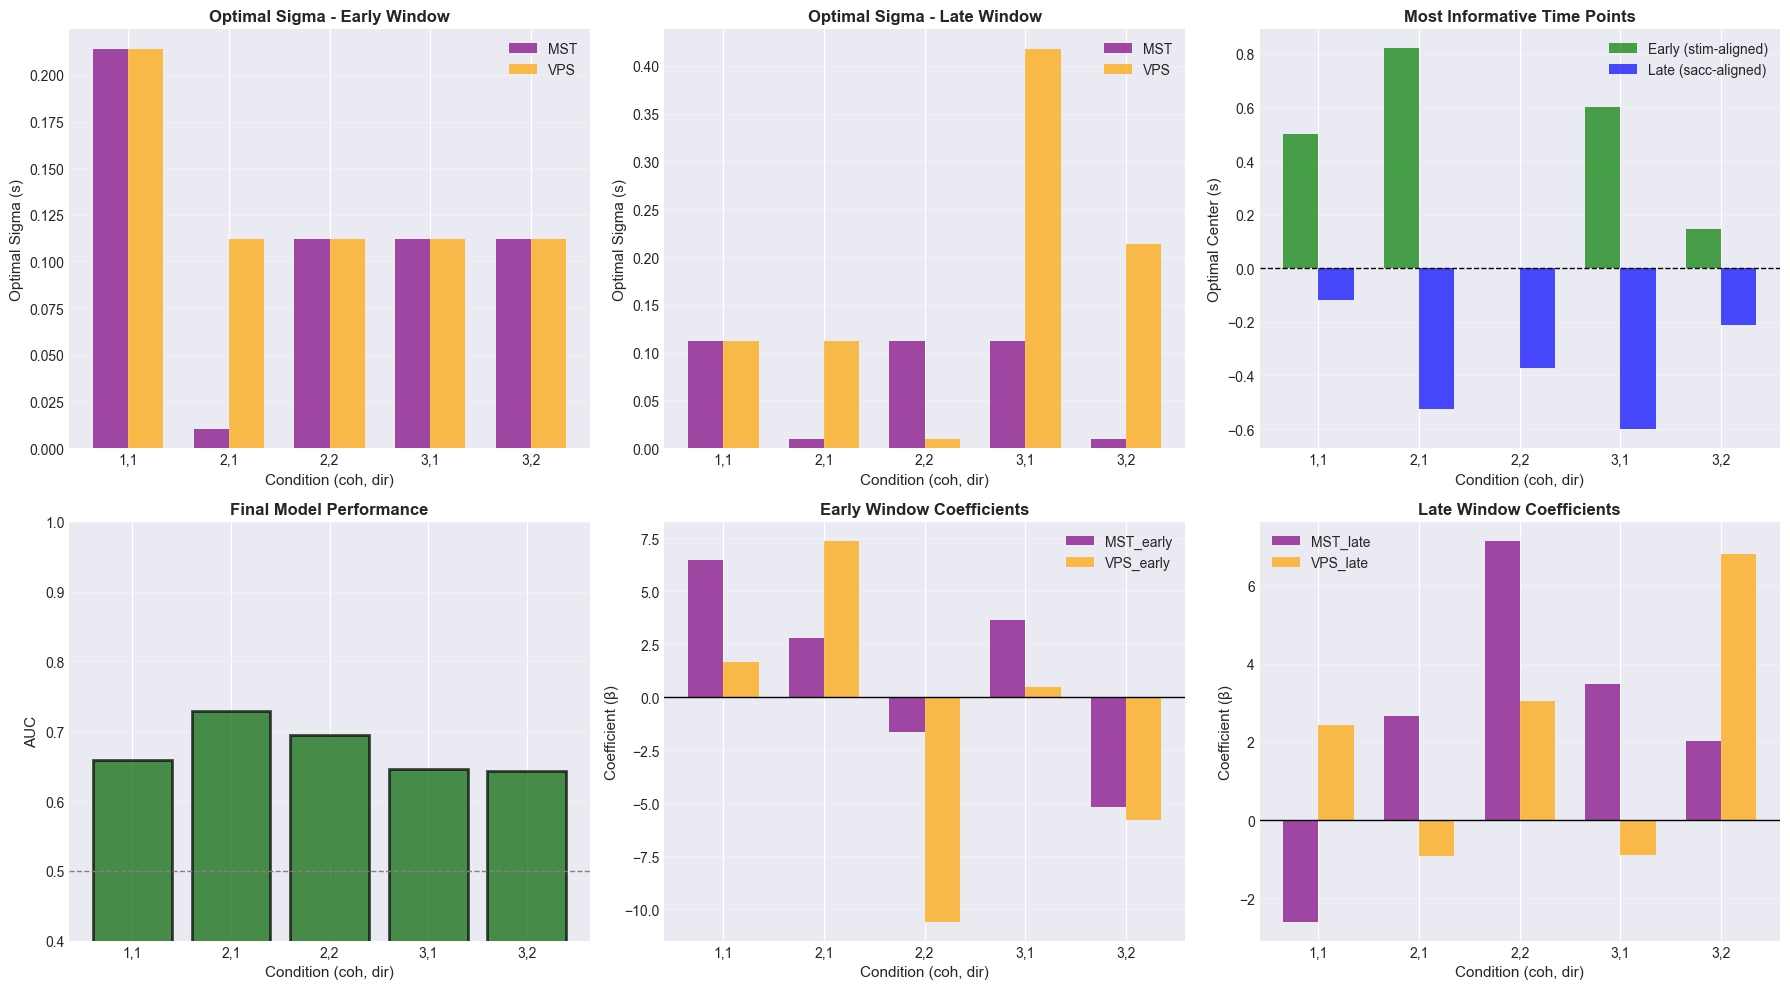


Results saved to: D:\Neural-Pipeline\results\accumulated_evidence\processed_data\all_results_choice.npy

ANALYSIS COMPLETE!


In [6]:
subject = 'zarya'
dates = ["20250702", "20250710", "20250523", "20250501", "20250417", "20250602"]
regress_type = 'noregress'

analyzer = initialize_analyzer(subject, dates, regress_type)

# Analysis parameters
target = 'choice'
areas = ['MST', 'VPS']
early_alignment = 'stimOn'
late_alignment = 'saccOnset'

# RT-adaptive windows
use_rt_adaptive = True
rt_buffer_early = 0.1
rt_buffer_late = 0.1

# NEW: Sigma selection and scanning parameters
sigma_values =  np.linspace(0.01, 5, 50)
n_sigma_centers = 4              # Centers during sigma selection (25%, 50%, 75%, 100%)
n_scan_centers = 20              # Centers during temporal scanning (fine-grained)
bootstrap_iterations = 1000      # Bootstrap iterations for CIs

# Define conditions to analyze
conditions = [(1, 1), (2, 1), (2, 2), (3, 1), (3, 2)]

# Storage for all results
all_results = {}

# Run pipeline for each condition
for condition in conditions:
    try:
        results = run_new_pipeline(
            analyzer=analyzer,
            condition=condition,
            target=target,
            areas=areas,
            early_alignment=early_alignment,
            late_alignment=late_alignment,
            use_rt_adaptive=use_rt_adaptive,
            rt_buffer_early=rt_buffer_early,
            rt_buffer_late=rt_buffer_late,
            sigma_values=sigma_values,
            n_sigma_centers=n_sigma_centers,
            n_scan_centers=n_scan_centers,
            bootstrap_iterations=bootstrap_iterations
        )
        
        if results is not None:
            all_results[condition] = results
            
    except Exception as e:
        print(f"\nERROR processing condition {condition}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

# Generate summary visualizations and tables
if all_results:
    print_summary_table(all_results)
    plot_summary_across_conditions(all_results, analyzer, target)
    
    # Save results
    results_path = analyzer.save_dir / 'processed_data' / f'all_results_{target}.npy'
    np.save(results_path, all_results, allow_pickle=True)
    print(f"\nResults saved to: {results_path}")

print("\n" + "="*100)
print("ANALYSIS COMPLETE!")
print("="*100)